# Compute correlations with metadata
## Setup
### Import packages

In [1]:
import logging
import re
import textwrap
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import gurobipy as gp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optlang
import pandas as pd
import seaborn as sns
import sympy
from cobra import DictList, Reaction
from cobra.flux_analysis.variability import (find_blocked_reactions,
                                             flux_variability_analysis)
from cobra.util.array import create_stoichiometric_matrix, nullspace
from mpl_toolkits.axes_grid1 import make_axes_locatable
from rbc_gem_utils import (ANNOTATION_PATH, COBRA_CONFIGURATION, CURATION_PATH,
                           DATABASE_PATH, GEM_NAME, INTERIM_PATH,
                           PARAMETERIZATION_PATH, PROCESSED_PATH, ROOT_PATH,
                           build_string, check_database_version_online,
                           check_version, compare_tables, explode_column,
                           get_annotation_df, read_cobra_model, read_rbc_model,
                           show_versions, split_string, visualize_comparison,
                           write_cobra_model)
from rbc_gem_utils.analysis.overlay import *
from rbc_gem_utils.database.uniprot import (UNIPROT_DB_TAG,
                                            UNIPROT_ISOFORM_ID_RE,
                                            UNIPROT_PATH)
from rbc_gem_utils.qc import reset_reaction_bounds, reset_subsystem_groups
from rbc_gem_utils.util import (AVOGADRO_NUMBER, DEFAULT_DRY_MASS_PER_CELL,
                                convert_gDW_to_L, convert_L_to_gDW,
                                ensure_iterable, log_msg, strip_plural)
from rbc_gem_utils.visualization import cmap_map
from scipy.cluster.hierarchy import linkage
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from sympy import parse_expr

gp.setParam("OutputFlag", 0)
gp.setParam("LogToConsole", 0)

# Show versions of notebook
show_versions()
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

Set parameter Username

Package Information
-------------------
rbc-gem-utils 0.0.1

Dependency Information
----------------------
beautifulsoup4                       4.12.3
bio                                 missing
cobra                                0.29.1
depinfo                               2.2.0
gurobipy                             11.0.3
matplotlib                           3.10.0
matplotlib-venn                       1.1.1
memote                               0.17.0
networkx                              3.4.2
notebook                              7.3.2
openpyxl                              3.1.5
pandas                                2.2.3
pre-commit                            4.1.0
rbc-gem-utils[database,network,vis] missing
requests                             2.32.3
scipy                                1.15.1
seaborn                              0.13.2

Build Tools Information
-----------------------
pip          24.2
setuptools 75.1.0
wheel      0.44.0

Platform Informat

### Define configuration
#### COBRA Configuration

In [2]:
COBRA_CONFIGURATION.solver = "gurobi"
# Set bound defaults much larger to prevent model loading issues
COBRA_CONFIGURATION.bounds = (-1e8, 1e8)
COBRA_CONFIGURATION

Attribute,Description,Value
solver,Mathematical optimization solver,gurobi
tolerance,"General solver tolerance (feasibility, integrality, etc.)",1e-07
lower_bound,Default reaction lower bound,-100000000.0
upper_bound,Default reaction upper bound,100000000.0
processes,Number of parallel processes,127
cache_directory,Path for the model cache,C:\Users\Alicia Key\AppData\Local\opencobra\cobrapy\Cache
max_cache_size,Maximum cache size in bytes,104857600
cache_expiration,Model cache expiration time in seconds (if any),None


## Load RBC-GEM model

In [3]:
# model_id = "RBC_GEM"

# data_path = Path(f"{ROOT_PATH}/data/analysis/OVERLAY").resolve()
# results_path = Path(f"{ROOT_PATH}{PROCESSED_PATH}/{model_id}/OVERLAY")
# results_path.mkdir(exist_ok=True, parents=True)

# imagetype = "svg"
# transparent = True
# save_figures = True

# dataset_name = "RBComics"
# pcmodel_dirpath = Path(f"{data_path}/{model_id}")
# dataset_path = Path(f"{results_path}/{dataset_name}")
# dataset_models_dirpath = Path(f"{dataset_path}/pcmodels")

# sample_prefix, time_prefix = ("S", "D")
# # Integers are easier to work with for time points
# timepoints = [10, 23, 42]

# model = read_cobra_model(filename=f"{pcmodel_dirpath}/{model_id}.xml")
# pcmodel = load_overlay_model(filename=f"{pcmodel_dirpath}/{model_id}_PC.xml")

# # For this workflow, shut off complex dilution reactions at the start
# for cplx_dilution in pcmodel.reactions.query(lambda x: isinstance(x, ComplexDilution)):
#     cplx_dilution.bounds = (0, 0)

# pcmodel

model_id = "RBC3P"

data_path = Path("../../../../data/analysis/OVERLAY").resolve()
root_path = Path("../../../..").resolve()
results_path = root_path / "data" / "processed" / model_id / "OVERLAY"
results_path.mkdir(exist_ok=True, parents=True)

imagetype = "svg"
transparent = True
save_figures = True

dataset_name = "RBComics"
pcmodel_dirpath = data_path / model_id
dataset_path = results_path / dataset_name
dataset_models_dirpath = dataset_path / "pcmodels"

sample_prefix, time_prefix = ("S", "D")
# Integers are easier to work with for time points
timepoints = [10, 23, 42]

model_filename = pcmodel_dirpath / f"{model_id}.xml"
model = read_cobra_model(filename=model_filename)
pcmodel_filename = pcmodel_dirpath / f"{model_id}_PC.xml"
pcmodel = load_overlay_model(filename=pcmodel_filename)

# For this workflow, shut off complex dilution reactions at the start
for cplx_dilution in pcmodel.reactions.query(lambda x: isinstance(x, ComplexDilution)):
    cplx_dilution.bounds = (0, 0)

pcmodel

Name,RBC3P_PC
Memory address,17b6b685bb0
Number of metabolites,489
Number of reactions,935
Number of genes,103
Number of groups,10
Objective expression,1.0*NaKt - 1.0*NaKt_reverse_db47e
Compartments,"cytosol, extracellular space, protein compartment"


## Load pcFVA generated results

In [4]:
# pcfva_results_dirpath = Path(f"{dataset_path}/pcFVA")
# corr_results_dirpath = Path(f"{dataset_path}/correlations")

pcfva_results_dirpath = dataset_path / "pcFVA" 
corr_results_dirpath = dataset_path / "correlations"
print(pcfva_results_dirpath)
print(corr_results_dirpath)

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P\OVERLAY\RBComics\pcFVA
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P\OVERLAY\RBComics\correlations


In [5]:
# Test to see if results were recently generated in this run, otherwise load DataFrame of generated results

try:
    assert not df_pcfva_all.empty
except (NameError, AssertionError):
    df_pcfva_all = pd.read_csv(
        f"{pcfva_results_dirpath}/{pcmodel.id}_FVAresults_ALL.tsv",
        sep="\t",
        index_col=None,
    )

df_pcfva_all

,reactions,optimum,model,minimum,maximum
0,ADA,0.0,RBC3P_PC_Mean_D10,0.0,4.262314
1,ADA,0.0,RBC3P_PC_Mean_D23,0.0,4.264905
2,ADA,0.0,RBC3P_PC_Mean_D42,0.0,4.262908
3,ADA,0.0,RBC3P_PC_Median_D10,0.0,4.263931
4,ADA,0.0,RBC3P_PC_Median_D23,0.0,4.264808
...,...,...,...,...,...
3852607,TPI,0.9,RBC3P_PC_S99_D23,0.0,0.211217
3852608,TPI,0.9,RBC3P_PC_S99_D42,0.0,0.211848
3852609,TPI,0.9,RBC3P_PC_S9_D10,0.0,0.210419
3852610,TPI,0.9,RBC3P_PC_S9_D23,0.0,0.209489


In [6]:
def get_sample_from_id(model_id, sample_prefix=""):
    sample = model_id.rsplit("_", 2)[-2]
    try:
        return int(sample.replace(sample_prefix, ""))
    except ValueError:
        return sample


def get_time_from_id(model_id, time_prefix=""):
    time = model_id.rsplit("_", 2)[-1]
    try:
        return int(time.replace(time_prefix, ""))
    except ValueError:
        return time

In [7]:
list_of_pcmodels = list(df_pcfva_all["model"].unique())
operation_model_ids = sorted(
    [
        x
        for x in list_of_pcmodels
        if not isinstance(get_sample_from_id(x, sample_prefix), (int, float))
    ],
    key=lambda x: (
        get_sample_from_id(x, sample_prefix),
        get_time_from_id(x, time_prefix),
    ),
)
operations = set([get_sample_from_id(x, sample_prefix) for x in operation_model_ids])
operations

{'Mean', 'Median'}

In [8]:
enzyme_total_suffix = DEFAULT_ENZYME_TOTAL_SUFFIX
min_reaction_list = model.reactions.query(lambda x: x.gene_reaction_rule).list_attr(
    "id"
)
enzymes_list = pcmodel.reactions.query(
    lambda x: x.id.startswith(f"ENZDL_enzyme_") and f"{enzyme_total_suffix}" in x.id
).list_attr("id")
reaction_enzymes_map = {
    rid: tuple(
        pcmodel.reactions.query(
            lambda x: x.id.startswith(f"ENZDL_enzyme_{rid}_")
        ).list_attr("id")
    )
    for rid in min_reaction_list
}
enzyme_reaction_map = {
    enzyme: rid for rid, enzymes in reaction_enzymes_map.items() for enzyme in enzymes
}
if not enzymes_list:
    enzymes_list = [
        enzyme
        for enzyme, rid in enzyme_reaction_map.items()
        if rid in min_reaction_list
    ]
min_reaction_list += enzymes_list
print(
    f"Number of reactions minimize/maximize (minimum): {len(min_reaction_list)} / {len(pcmodel.reactions)}"
)

Number of reactions minimize/maximize (minimum): 116 / 935


### Parse main results into smaller DataFrames
#### Seperate by reaction variable types

In [9]:
# Initialize entries with prefixes used for seperating DataFrames
dict_of_dataframes_types = {
    "reactions": None,
    "proteins": "PROTDL",
    # "complexes": "CPLXFM",
    # "complex_dilutions": "CPLXDL",
    "enzymes": "ENZDL",
    # "enzyme_formation": "ENZFM",
    "budgets": "PBDL",
    "relaxation": "RELAX",
}
for key, prefix in dict_of_dataframes_types.copy().items():
    if prefix:
        df = df_pcfva_all[
            df_pcfva_all["reactions"].apply(lambda x: x.startswith(prefix))
        ]
    else:
        df = df_pcfva_all[
            df_pcfva_all["reactions"].apply(lambda x: x in model.reactions)
        ]
    dict_of_dataframes_types[key] = df.copy()

dict_of_dataframes_types;

#### Seperate by optimum value

In [10]:
# dict_of_dataframes_opt = {
#     optimum: df_pcfva_all[df_pcfva_all["optimum"] == optimum].copy()
#     for optimum in df_pcfva_all["optimum"].unique()
# }
# print(list(dict_of_dataframes_opt))

#### Seperate by model

In [11]:
# dict_of_dataframes_model = {
#     model_id: df_pcfva_all[df_pcfva_all["model"] == model_id].copy()
#     for model_id in df_pcfva_all["model"].unique()
# }
# print(list(dict_of_dataframes_model))

### Create DataFrame for correlation calculations
#### Get maximum reaction fluxes and associated expression values

In [12]:
groupby_list = ["model", "reactions"]
always_expression_independent = [
    r.id for r in model.reactions.query(lambda x: not x.boundary and not x.genes)
]
print(
    f"Number of reactions w/o genes, always expression independent: {len(always_expression_independent)}"
)
always_expression_independent;

Number of reactions w/o genes, always expression independent: 4


##### Get maximum reaction flux

In [13]:
# Get the maximum value of the reaction flux in each direction, regardless of percent optimum
df = dict_of_dataframes_types["reactions"].copy()
df = df.groupby(groupby_list)[["minimum", "maximum"]].agg(
    {
        "minimum": "min",
        "maximum": "max",
    }
)
df_max_flux_per_model = df.abs().max(axis=1)
df_max_flux_per_model.name = "Flux"
df_max_flux_per_model

model              reactions
RBC3P_PC_Mean_D10  ADA          4.262314
                   ADEt         0.440828
                   ADK1         0.440828
                   ADNK1        0.440828
                   ADNt         4.120981
                                  ...   
RBC3P_PC_S9_D42    SPODM        2.033364
                   TALA         0.703845
                   TKT1         0.703845
                   TKT2         0.703845
                   TPI          0.836251
Name: Flux, Length: 157590, dtype: float64

##### Get maximum flux range

In [14]:
# Determine flux range
df = dict_of_dataframes_types["reactions"].copy()
df["Range"] = df["maximum"] - df["minimum"]
df_flux_range_per_model = df.groupby(groupby_list)["Range"].max()
df_flux_range_per_model

model              reactions
RBC3P_PC_Mean_D10  ADA          4.262314
                   ADEt         0.440828
                   ADK1         0.440828
                   ADNK1        0.440828
                   ADNt         4.561808
                                  ...   
RBC3P_PC_S9_D42    SPODM        2.033364
                   TALA         1.391606
                   TKT1         1.391606
                   TKT2         1.391606
                   TPI          0.836251
Name: Range, Length: 157590, dtype: float64

##### Get maximum expression

In [15]:
# Determine expression association with reaction
df = dict_of_dataframes_types["enzymes"].copy()
df["reactions"] = df["reactions"].apply(lambda x: enzyme_reaction_map[x])
df_max_enzyme_per_model = df.groupby(groupby_list)["maximum"].max()
df_max_enzyme_per_model.name = "Expression"
df_max_enzyme_per_model

model              reactions
RBC3P_PC_Mean_D10  ADA           48.270489
                   ADEt          64.176258
                   ADK1         162.463643
                   ADNK1         49.096208
                   ADNt          35.143099
                                   ...    
RBC3P_PC_S9_D42    SPODM        113.864368
                   TALA          18.763571
                   TKT1           6.685875
                   TKT2           6.685875
                   TPI           42.362017
Name: Expression, Length: 107532, dtype: float64

##### Merge into one DataFrame

In [16]:
df_reaction_flux_expression = (
    pd.merge(
        df_max_flux_per_model,
        df_flux_range_per_model,
        left_index=True,
        right_index=True,
    )
    .merge(df_max_enzyme_per_model, left_index=True, right_index=True)
    .reset_index(drop=False)
)
df_reaction_flux_expression

,model,reactions,Flux,Range,Expression
0,RBC3P_PC_Mean_D10,ADA,4.262314,4.262314,48.270489
1,RBC3P_PC_Mean_D10,ADEt,0.440828,0.440828,64.176258
2,RBC3P_PC_Mean_D10,ADK1,0.440828,0.440828,162.463643
3,RBC3P_PC_Mean_D10,ADNK1,0.440828,0.440828,49.096208
4,RBC3P_PC_Mean_D10,ADNt,4.120981,4.561808,35.143099
...,...,...,...,...,...
107527,RBC3P_PC_S9_D42,SPODM,2.033364,2.033364,113.864368
107528,RBC3P_PC_S9_D42,TALA,0.703845,1.391606,18.763571
107529,RBC3P_PC_S9_D42,TKT1,0.703845,1.391606,6.685875
107530,RBC3P_PC_S9_D42,TKT2,0.703845,1.391606,6.685875


### Define helper methods

In [17]:
def prepare_correlation_df(df, pvalue_tol):
    df["pvalue"] = df["pvalue"].apply(
        lambda x: -np.log10(x if x >= pvalue_tol else pvalue_tol)
    )
    df = df.sort_values(["pvalue", "rho"], ascending=[False, False])
    return df


def plot_correlations(
    df, ax=None, histx=True, histy=True, colorbar=True, vertical_lines=None, **kwargs
):
    # Define figure if no axes provided.
    scatter_inch = kwargs.get("scatter_inch", 5.0)
    hist_inch = kwargs.get("hist_inch", 1.0)
    hist_pad = kwargs.get("hist_pad", 0.25)
    if ax is None:
        _, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(
                scatter_inch + (hist_inch + hist_pad if histy else 0),
                scatter_inch + (hist_inch + hist_pad if histx else 0),
            ),
        )
    # X-axis is rho, Y-axis is expected as -log10(pvalue) from correlation prep
    xy = {"x": "rho", "y": "pvalue"}
    limits = {
        "x": (kwargs.get("xmin", -1.0), kwargs.get("xmax", 1.0)),
        "y": (kwargs.get("ymin", 0.0), kwargs.get("ymax", df[xy["y"]].max())),
    }
    pads = {
        axis: kwargs.get(f"{axis}pad", (limits[axis][1] - limits[axis][0]) / 2 / 20)
        for axis in list(xy)
    }
    cmap = kwargs.get("cmap", "viridis")
    zorder = kwargs.get("zorder", 2)
    edgecolor = kwargs.get("edgecolor", "black")
    edgewidth = kwargs.get("edgewidth", 0.5)
    scatter = ax.scatter(
        xy["x"],
        xy["y"],
        data=df,
        c=kwargs.get("c", xy["y"]),
        s=kwargs.get("s", 40),
        zorder=zorder,
        edgecolor=edgecolor,
        linewidth=edgewidth,
        cmap=mpl.colormaps.get_cmap(cmap) if isinstance(cmap, str) else cmap,
        norm=mpl.colors.Normalize(
            vmin=limits["y"][0] - pads["y"], vmax=limits["y"][1] + pads["y"]
        ),
    )
    ax.set_xlabel(r"Spearman Correlation $(\rho)$", fontdict={"size": "xx-large"})
    ax.set_ylabel("-log$_{10}$(p-value)", fontdict={"size": "xx-large"})
    ax.set_xlim((limits["x"][0] - pads["x"], limits["x"][1] + pads["x"]))
    ax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))

    major_ticks = {axis: kwargs.get(f"{axis}tick_major") for axis in list(xy)}
    minor_ticks = {
        axis: kwargs.get(
            f"{axis}tick_minor",
            major_ticks[axis] / 2 if major_ticks[axis] is not None else None,
        )
        for axis in list(xy)
    }
    for axis in list(xy):
        if major_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_major_locator(
                mpl.ticker.MultipleLocator(major_ticks[axis])
            )
        if minor_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_minor_locator(
                mpl.ticker.MultipleLocator(minor_ticks[axis])
            )
        ax.tick_params(axis=axis, labelsize="large")

    if vertical_lines:
        for lineval, (lineprops, textprops) in vertical_lines.items():
            if lineprops:
                ax.vlines(
                    x=lineval,
                    ymin=limits["y"][0] - pads["y"],
                    ymax=limits["y"][1] + pads["y"],
                    **lineprops,
                )
            if textprops:
                ax.text(x=lineval + pads["x"] / 2, transform=ax.transData, **textprops)

    if kwargs.get("grid", False):
        ax.grid(True, **dict(which="both", alpha=0.75))

    if colorbar:
        cax = ax.inset_axes(
            [
                limits["x"][0] - pads["x"],  # lower left corner xpos
                limits["y"][0] - pads["y"],  # lower left corner ypos
                pads["x"],  # width of colorbar
                limits["y"][1]
                + pads["y"]
                + pads[
                    "y"
                ],  # height of colorbar, need extra ypad to make up for lowering ypos
            ],
            transform=ax.transData,
        )
        cbar = ax.get_figure().colorbar(scatter, cax=cax)
        cax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))
        cax.set_xticks([])
        cax.set_yticks([])

    ax_histx = None
    ax_histy = None
    if histx or histy:
        divider = make_axes_locatable(ax)
        # Histogram axes
        ax_histx = (
            divider.append_axes("top", hist_inch, pad=hist_pad, sharex=ax)
            if histx
            else None
        )
        ax_histy = (
            divider.append_axes("right", hist_inch, pad=hist_pad, sharey=ax)
            if histy
            else None
        )

        for axis, ax_hist in zip(list(xy), [ax_histx, ax_histy]):
            if ax_hist is None:
                continue
            binwidth = kwargs.get(
                f"{axis}binwidth",
                (
                    minor_ticks[axis]
                    if minor_ticks[axis] is not None
                    else major_ticks[axis]
                ),
            )
            counts, bins, patches = ax_hist.hist(
                df[xy[axis]],
                bins=np.arange(limits[axis][0], limits[axis][1] + binwidth, binwidth),
                orientation="vertical" if axis == "x" else "horizontal",
                zorder=zorder,
                edgecolor=edgecolor,
                linewidth=edgewidth,
            )
            other = "y" if axis == "x" else "x"
            ax_hist.tick_params(
                axis=axis, **{f"label{'bottom' if axis == 'x' else 'left'}": False}
            )
            ax_hist.tick_params(axis=other, labelsize="large")
            getattr(ax_hist, f"set_{other}label")("Frequency", fontsize="large")

            tick_major_int = kwargs.get(f"hist{axis}_{other}tick_major")
            if tick_major_int is not None:
                getattr(ax_hist, f"{other}axis").set_major_locator(
                    mpl.ticker.MultipleLocator(tick_major_int)
                )
                getattr(ax_hist, f"{other}axis").set_minor_locator(
                    mpl.ticker.MultipleLocator(tick_major_int / 2)
                )
            getattr(ax_hist, f"set_{other}lim")((0, max(counts) * 1.1))
            if kwargs.get("grid", False):
                ax_hist.grid(True, **dict(which="both", alpha=0.75))

            if vertical_lines and (axis == "x" and ax_hist is not None):
                for lineval, (lineprops, _) in vertical_lines.items():
                    if lineprops:
                        ax_hist.vlines(
                            x=lineval, ymin=0.0, ymax=max(counts) * 1.1, **lineprops
                        )

    return ax, ax_histx, ax_histy

### Create subgroups of models 

In [18]:
# Don't include mean/median in correlation calculations
model_groups = {
    "ALL": [
        x
        for x in list_of_pcmodels
        if not any([op.capitalize() in x for op in operations])
    ],
    "OPERATIONS": operation_model_ids,
}
# model_groups.update({
#     f"{time_prefix}{time}": [x for x in model_groups["ALL"] if x.endswith(f"{time_prefix}{time}")]
#     for time in timepoints
# })
list(model_groups)

['ALL', 'OPERATIONS']

### Compute correlations with metadata

In [19]:
df_metadata = pd.read_csv(
    f"{data_path}/{dataset_name}/Proteomics_Metadata.tsv", sep="\t", index_col=0
)
df_metadata = df_metadata.convert_dtypes()

numeric_metadata_columns = df_metadata.select_dtypes(include="number").columns
other_metadata_columns = df_metadata.select_dtypes(exclude="number").columns
# Map to models
df_pcmodel_meta = pd.DataFrame.from_dict(
    {
        pcmodel_id: pcmodel_id.replace(f"{pcmodel.id}_", "").split("_")[0]
        for pcmodel_id in list_of_pcmodels
    },
    orient="index",
    columns=["donor"],
)
sample_ids = set(df_pcmodel_meta["donor"].unique())
# Handle models generated using operations such as mean, median, and quantile
to_concat = []
operations = set(
    [
        get_sample_from_id(x, sample_prefix)
        for x in list_of_pcmodels
        if isinstance(get_sample_from_id(x, sample_prefix), str)
    ]
)
for op in operations:
    if op in sample_ids:
        df = getattr(
            df_metadata.loc[list(sample_ids.difference(operations))],
            op.lower(),
        )(axis=0, numeric_only=True)
        df.name = op
        to_concat.append(df)


df_metadata = pd.concat([df_metadata.T] + to_concat, axis=1).T
df_pcmodel_meta = df_pcmodel_meta.merge(df_metadata, left_on="donor", right_index=True)
df_pcmodel_meta

,donor,AS,Gender,DONDB.ABO_RH,RBCOmics.Race.Ethnicity.Group,Age,BMI,Weight,Height,Hemolysis.volume,...,Adjusted.Osmotic.Hemolysis,Adjusted.Oxidative.Hemolysis,CBC.WBC,CBC.RBC,CBC.HGB,CBC.HCT,CBC.MCV,CBC.RDW,CBC.PLT,Ferritin
RBC3P_PC_Mean_D10,Mean,<NA>,<NA>,<NA>,<NA>,50.573052,27.813184,182.025974,67.715909,11.370942,...,31.870944,33.8469,6.522781,4.753179,13.975083,42.21995,89.157368,13.912583,245.023179,43.086437
RBC3P_PC_Mean_D23,Mean,<NA>,<NA>,<NA>,<NA>,50.573052,27.813184,182.025974,67.715909,11.370942,...,31.870944,33.8469,6.522781,4.753179,13.975083,42.21995,89.157368,13.912583,245.023179,43.086437
RBC3P_PC_Mean_D42,Mean,<NA>,<NA>,<NA>,<NA>,50.573052,27.813184,182.025974,67.715909,11.370942,...,31.870944,33.8469,6.522781,4.753179,13.975083,42.21995,89.157368,13.912583,245.023179,43.086437
RBC3P_PC_Median_D10,Median,<NA>,<NA>,<NA>,<NA>,53.0,26.563091,175.0,68.0,11.0,...,30.137637,33.787066,6.2,4.71,13.9,42.075,89.6,13.625,239.0,27.0
RBC3P_PC_Median_D23,Median,<NA>,<NA>,<NA>,<NA>,53.0,26.563091,175.0,68.0,11.0,...,30.137637,33.787066,6.2,4.71,13.9,42.075,89.6,13.625,239.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RBC3P_PC_S99_D23,S99,AS3,M,O+,CAUCASIAN,23,20.085714,140,70,11.0,...,57.835737,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,20.0
RBC3P_PC_S99_D42,S99,AS3,M,O+,CAUCASIAN,23,20.085714,140,70,11.0,...,57.835737,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,20.0
RBC3P_PC_S9_D10,S9,AS3,M,O+,CAUCASIAN,27,25.675676,200,74,11.75,...,33.494795,<NA>,5.76,4.96,15.0,44.1,88.9,12.6,280.0,32.0
RBC3P_PC_S9_D23,S9,AS3,M,O+,CAUCASIAN,27,25.675676,200,74,11.75,...,33.494795,<NA>,5.76,4.96,15.0,44.1,88.9,12.6,280.0,32.0


#### Identify all possible pairs of columns for correlation computations

In [20]:
for i, metadata_col in enumerate(numeric_metadata_columns, start=1):
    print(f"{i}:\t{metadata_col}")

1:	Age
2:	BMI
3:	Weight
4:	Height
5:	Hemolysis.volume
6:	Hemolysis.hct
7:	Hemolysis.storage_total_hb
8:	Hemolysis.storage_pct_hemol
9:	Hemolysis.pink_total_hb
10:	Hemolysis.pink_pct_hemol
11:	Recall.Transfer.Storage.Hemolysis
12:	Recall.Transfer.Osmotic.Hemolysis
13:	Recall.Transfer.Oxidative.Hemolysis
14:	Adjusted.Storage.Hemolysis
15:	Adjusted.Osmotic.Hemolysis
16:	Adjusted.Oxidative.Hemolysis
17:	CBC.WBC
18:	CBC.RBC
19:	CBC.HGB
20:	CBC.HCT
21:	CBC.MCV
22:	CBC.RDW
23:	CBC.PLT
24:	Ferritin


#### Compute all pairs of correlations
Can take a significant amount of time the first time computed.

In [21]:
verbose = False
display_top_nhits = 10
reaction_list = list(df_reaction_flux_expression["reactions"].unique())
corr_results_dirpath.mkdir(exist_ok=True, parents=True)

In [22]:
# Keep off to use previously computed results. Does not work if results not previously computed
run_computations = True
group_name = "ALL"
metadata_columns_for_corr = [
    # Comment/Uncomment to control desired columns
    "Age",
    "BMI",
    "Weight",
    "Height",
    "Hemolysis.volume",
    "Hemolysis.hct",
    "Hemolysis.storage_total_hb",
    "Hemolysis.storage_pct_hemol",
    "Hemolysis.pink_total_hb",
    "Hemolysis.pink_pct_hemol",
    "Recall.Transfer.Storage.Hemolysis",
    "Recall.Transfer.Osmotic.Hemolysis",
    "Recall.Transfer.Oxidative.Hemolysis",
    "Adjusted.Storage.Hemolysis",
    "Adjusted.Osmotic.Hemolysis",
    "Adjusted.Oxidative.Hemolysis",
    "CBC.WBC",
    "CBC.RBC",
    "CBC.HGB",
    "CBC.HCT",
    "CBC.MCV",
    "CBC.RDW",
    "CBC.PLT",
    "Ferritin",
]

if group_name in operations or group_name == "OPERATIONS":
    raise Exception("Cannot use models created using data from statistical operations.")

group_model_list = model_groups[group_name]
group_results_dir = Path(f"{corr_results_dirpath}/{group_name}")
group_results_dir.mkdir(exist_ok=True, parents=True)

metadata_rankings_group_dict = defaultdict(dict)
for metadata_col in metadata_columns_for_corr:
    for column_pair in [("Flux", metadata_col), ("Expression", metadata_col)]:
        filepath = Path(f"{group_results_dir}/{column_pair[0]}_{column_pair[1]}.tsv")
        if filepath.exists():
            print(
                "Already computed correlations between '{}' and '{}' for '{}' models".format(
                    *column_pair, group_name
                )
            )
            df_correlations = pd.read_csv(f"{filepath}", sep="\t", index_col=0)
            df_correlations = df_correlations.loc[reaction_list]
        elif run_computations:
            print(
                "========================================================================="
            )
            print(
                "Computing correlations between '{}' and '{}' for '{}' models".format(
                    *column_pair, group_name
                )
            )
            print(
                "========================================================================="
            )
            correlations_dict = defaultdict(dict)
            metadata_cols = [
                col for col in column_pair if col in numeric_metadata_columns
            ]
            if any(metadata_cols):
                df_meta = df_pcmodel_meta.loc[:, metadata_cols].dropna()
                model_list = [m for m in group_model_list if m in df_meta.index]
            else:
                model_list = group_model_list.copy()
            for rid in reaction_list:
                df = df_reaction_flux_expression[
                    df_reaction_flux_expression["reactions"] == rid
                ]
                df = df.drop("reactions", axis=1)
                df = df.set_index("model")
                # Add metadata columns if needed
                if any(metadata_cols):
                    df = df.merge(
                        df_meta, left_index=True, right_index=True, how="inner"
                    ).dropna(axis=0)
                # Expected warnings emitted are due to constant input array, in which the correlation coefficient is not defined. Corresponds to the nan values.
                with warnings.catch_warnings(action="ignore"):
                    rho, pvalue = spearmanr(df.loc[model_list, list(column_pair)])
                correlations_dict[rid]["rho"] = rho
                correlations_dict[rid]["pvalue"] = pvalue
                if verbose:
                    print(f"For reaction {rid}: rho={rho}, p={pvalue}")
            df_correlations = pd.DataFrame.from_dict(correlations_dict, orient="index")
            df_correlations.to_csv(f"{filepath}", sep="\t", index=True)
        else:
            continue

        metadata_rankings_group_dict[group_name][column_pair] = df_correlations
        metadata_rankings_group_dict[group_name][column_pair]

Already computed correlations between 'Flux' and 'Age' for 'ALL' models
Already computed correlations between 'Expression' and 'Age' for 'ALL' models
Already computed correlations between 'Flux' and 'BMI' for 'ALL' models
Already computed correlations between 'Expression' and 'BMI' for 'ALL' models
Already computed correlations between 'Flux' and 'Weight' for 'ALL' models
Already computed correlations between 'Expression' and 'Weight' for 'ALL' models
Already computed correlations between 'Flux' and 'Height' for 'ALL' models
Already computed correlations between 'Expression' and 'Height' for 'ALL' models
Already computed correlations between 'Flux' and 'Hemolysis.volume' for 'ALL' models
Already computed correlations between 'Expression' and 'Hemolysis.volume' for 'ALL' models
Already computed correlations between 'Flux' and 'Hemolysis.hct' for 'ALL' models
Already computed correlations between 'Expression' and 'Hemolysis.hct' for 'ALL' models
Already computed correlations between 'Flu

In [23]:
# df_pathways = pd.read_csv(
#     f"{ROOT_PATH}{CURATION_PATH}/subsystems.tsv", sep="\t", index_col=0, dtype=str
# )

df_pathways_filename = root_path / "data" / "curation" / f"subsystems.tsv"
df_pathways = pd.read_csv(
    df_pathways_filename, sep="\t", index_col=0, dtype=str
)

cat_cols = ["subsystem", "category"]
df_pathways = df_pathways.fillna("").reset_index()

# Categories that should be excluded from the figure
categories_to_exclude = {"Pseudoreactions", "Model total"}
# Main categories in figure and abbreviations, all unmapped categories are mapped to "Other"
categories_to_keep = {
    "Amino acid metabolism": mpl.cm.spring,
    "Carbohydrate metabolism": mpl.cm.Greens,
    "Lipid metabolism": mpl.cm.Blues,
    "Metabolism of cofactors and vitamins": mpl.cm.summer,
    "Nucleotide metabolism": mpl.cm.winter,
    "Reactive species": mpl.cm.Reds,
    "Transport reactions": mpl.cm.Purples,
    "Other": mpl.cm.gray_r,
}
use_abbrevs = True
abbrevs = {
    "Amino acid metabolism": "A",
    "Carbohydrate metabolism": "C",
    "Lipid metabolism": "L",
    "Metabolism of cofactors and vitamins": "V",
    "Nucleotide metabolism": "N",
    "Reactive species": "R",
    "Transport reactions": "T",
    "Other": "O",
}
barsize = 0.8
cmax = 0.8
cmin = 0.15


colormaps_normal = dict(
    zip(
        categories_to_keep,
        [
            cmap_map(lambda x: x * 1, categories_to_keep[k])(cmax)
            for k in categories_to_keep
        ],
    )
)
category_colors = {key: tuple(value(cmax)) for key, value in categories_to_keep.items()}

# Group "Metabolism of other amino acids" with amino acids rather than treat as "other"
df_pathways["category"] = df_pathways["category"].replace(
    "Metabolism of other amino acids", "Amino acid metabolism"
)
df_pathways["category"] = df_pathways["category"].apply(
    lambda category: (
        "Other"
        if (
            category not in categories_to_keep and category not in categories_to_exclude
        )
        else category
    )
)
df_pathways = df_pathways.rename({"name": "subsystem"}, axis=1)
mapping_dict = df_pathways[cat_cols].set_index("subsystem").squeeze().to_dict()

In [24]:
to_concat = {
    ("Flux", "Expression"): pd.read_csv(
        f"{group_results_dir}/Flux_Expression.tsv", sep="\t", index_col=0
    )
}
to_concat.update(metadata_rankings_group_dict[group_name])
for key, df in to_concat.items():
    df = df.copy()
    df.columns = pd.MultiIndex.from_tuples(
        tuple([(" and ".join(key), col) for col in df.columns]),
        names=("Variables", "Spearman correlation"),
    )
    to_concat[key] = df

df_all_correlations = pd.concat(list(to_concat.values()), axis=1)
gene_map = {
    r: build_string(sorted([g.id for g in pcmodel.reactions.get_by_id(r).genes]))
    for r in df_all_correlations.index
}
df_all_correlations.index = pd.MultiIndex.from_tuples(
    [(r, gene_map[r]) for r in df_all_correlations.index], names=("reaction", "genes")
)
df_all_correlations = df_all_correlations.reset_index(drop=False)
df_all_correlations = df_all_correlations.sort_values(
    by=[
        ("Flux and Expression", "pvalue"),
        ("Flux and Expression", "rho"),
        ("genes", ""),
        ("reaction", ""),
    ],
    ascending=[True, False, True, True],
).set_index(["reaction", "genes"])
df_all_correlations["subsystem"] = [
    model.reactions.get_by_id(x[0]).subsystem for x in df_all_correlations.index
]
df_all_correlations["category"] = [
    mapping_dict[model.reactions.get_by_id(x[0]).subsystem]
    for x in df_all_correlations.index
]
df_all_correlations["category"] = df_all_correlations["category"].apply(
    lambda category: (
        "Other"
        if (
            category not in categories_to_keep and category not in categories_to_exclude
        )
        else category
    )
)
df_all_correlations.to_csv(
    f"{group_results_dir}/{pcmodel.id}_{dataset_name}_METADATA_CORRELATIONS.tsv",
    sep="\t",
    index=True,
)
df_all_correlations

Variables                                                     Flux and Expression  \
Spearman correlation                                                          rho   
reaction   genes                                                                    
AMPDA      AMPD3                                                         1.000000   
O2t        AQP1                                                          1.000000   
H2Ot       AQP1;AQP3                                                     1.000000   
CO2t       AQP1;RHAG;RHCE;RHD                                            1.000000   
CA2t       CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...            1.000000   
G6PDH2     G6PD                                                          1.000000   
PGI        GPI                                                           1.000000   
Kt1        GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...            1.000000   
NAt        GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...            1.000000   
NTDAMP     NT5C2                                                         1.000000   
NTDIMP     NT5C2                                                         1.000000   
PFK        PFKL;PFKM;PFKP                                                1.000000   
PYK        PKLR;PKM                                                      1.000000   
INSt       SLC29A1                                                       0.964976   
ADNt       SLC29A1                                                       0.931078   
NH4t       AQP1;AQP3;RHAG;RHCE;RHD                                       0.698461   
PYRt2      BSG;EMB;SLC16A1;SLC16A7                                       0.677079   
GAPD       GAPDH;GAPDHS                                                  0.666625   
ENO        ENO1;ENO2;ENO3                                                0.557587   
PPM        PGM2                                                          0.478476   
LDH_L      LDHA;LDHB                                                     0.394514   
RPI        RPIA                                                          0.359845   
HEX1       HK1;HK3                                                       0.359084   
CAATPS1    ATP2B1;ATP2B4                                                 0.342345   
ADNK1      ADK                                                           0.314025   
PGK        PGK1;PGK2                                                     0.302479   
NaKt       ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3                     0.293002   
PGL        PGLS                                                         -0.287718   
TPI        TPI1                                                          0.279213   
HXPRT      HPRT1                                                         0.251064   
GTHP       GPX1;GPX4                                                     0.248062   
DPGase     BPGM                                                         -0.237672   
RPE        RPE                                                           0.236650   
PPA        LHPP;PPA1;PPA2;PRUNE1                                         0.235328   
FBA        ALDOA;ALDOB;ALDOC                                             0.228328   
HYXNt      SLC29A1;SLC43A3                                               0.217215   
PUNP5      PNP                                                           0.171716   
PGM        BPGM;PGAM1                                                   -0.171346   
TKT1       TKT                                                           0.148380   
TKT2       TKT                                                           0.148380   
PRPPS      PRPS1;PRPS1L1;PRPS2                                           0.108831   
TALA       TALDO1                                                        0.107270   
GTHOy      GSR                                                          -0.104359   
GLC_Dt     SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                           0.093475   
GND  

In [25]:
row_method, row_metric = ("single", "euclidean")
col_method, col_metric = ("single", "euclidean")
row_cluster = True
col_cluster = True
# method, metric = ("average", "cityblock")
# row_method, row_metric = (method, metric)
# col_method, col_metric = (method, metric)
optimal_ordering = True
imagetype = "svg"

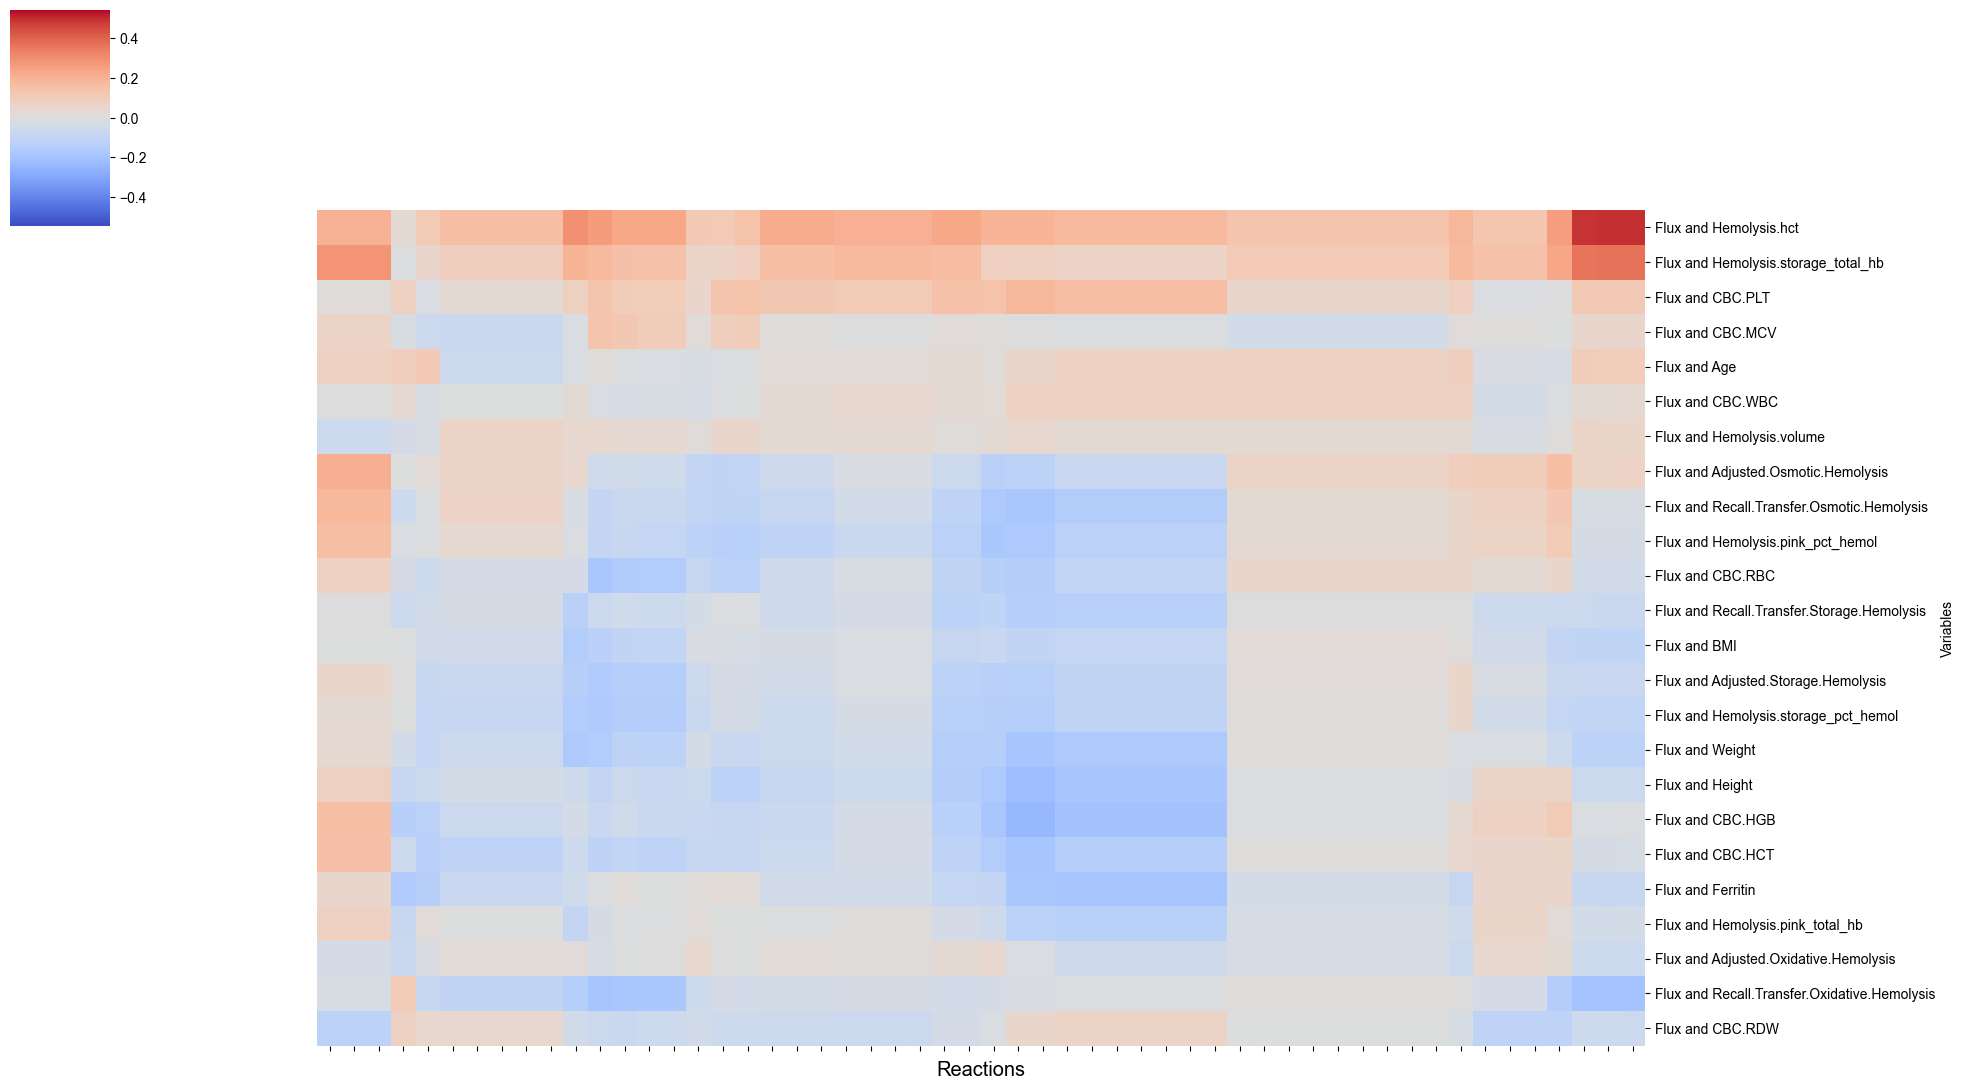

In [26]:
dtype = "Flux"
df_dtype = df_all_correlations.dropna().copy()
if "Flux and Expression" in df_dtype.columns:
    df_dtype = df_dtype.drop("Flux and Expression", level=0, axis=1)
df_dtype = df_dtype.loc[
    :, [x for x in df_dtype.columns if x[0].startswith(dtype) or x[0] in cat_cols]
]
df_dtype.to_csv(
    f"{dataset_path}/{pcmodel.id}_{dataset_name}_METADATA_{dtype.upper()}_CORRELATIONS.tsv",
    sep="\t",
    index=True,
)
df_dtype = df_dtype.loc[
    :, [x for x in df_dtype.columns if x[1] == "rho" or x[0] in cat_cols]
].droplevel(1, axis=1)
df_dtype

df_data = df_dtype.droplevel(1, axis=0)
df_data = df_data.loc[
    sorted(
        df_data.index,
        key=lambda x: (mapping_dict[model.reactions.get_by_id(x).subsystem], x),
    )
].T
df_data = df_data.loc[~df_data.index.isin(cat_cols)].astype(float)

# Cant exceed absolute value of 1
rho_lim = min(df_data.abs().max().max() * 1.1, 1)
fig = sns.clustermap(
    df_data,
    figsize=(20, 0.5 * len(df_data.index)),
    cmap="coolwarm",
    row_cluster=row_cluster,
    col_cluster=col_cluster,
    vmin=-rho_lim,
    vmax=rho_lim,
    row_linkage=linkage(
        df_data, method=row_method, metric=row_metric, optimal_ordering=optimal_ordering
    ),
    col_linkage=linkage(
        df_data.T,
        method=col_method,
        metric=col_metric,
        optimal_ordering=optimal_ordering,
    ),
    # col_colors=[category_colors[mapping_dict[model.reactions.get_by_id(x).subsystem]] for x in df_data.columns],
)
ax_heatmap = fig.ax_heatmap
ax_heatmap.set_xlabel("Reactions", fontsize="x-large")
ax_heatmap.xaxis.set_ticklabels([])
fig.ax_row_dendrogram.set_visible(False)
fig.ax_col_dendrogram.set_visible(False)
fig;

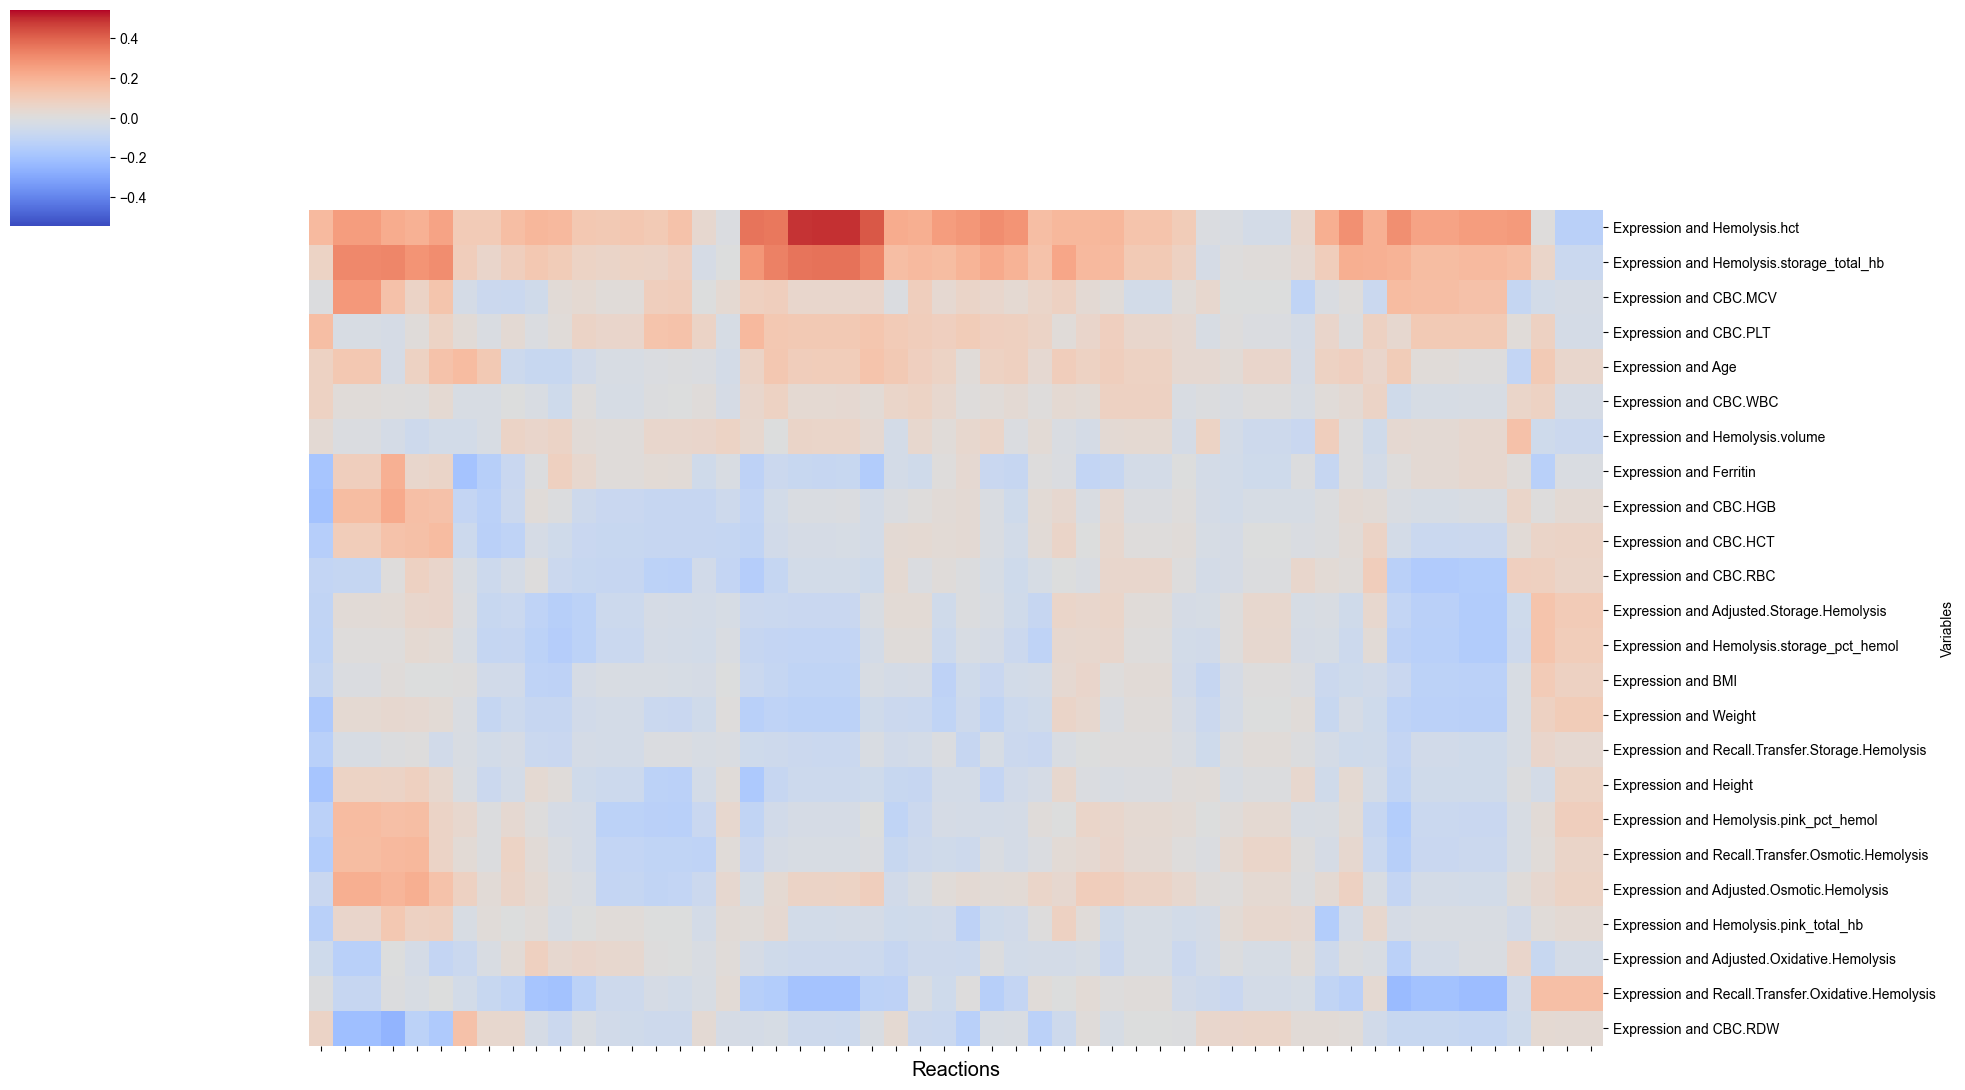

In [27]:
dtype = "Expr"
df_dtype = df_all_correlations.dropna().copy()
if "Flux and Expression" in df_dtype.columns:
    df_dtype = df_dtype.drop("Flux and Expression", level=0, axis=1)
df_dtype = df_dtype.loc[
    :, [x for x in df_dtype.columns if x[0].startswith(dtype) or x[0] in cat_cols]
]
df_dtype.to_csv(
    f"{dataset_path}/{pcmodel.id}_{dataset_name}_METADATA_{dtype.upper()}_CORRELATIONS.tsv",
    sep="\t",
    index=True,
)
df_dtype = df_dtype.loc[
    :, [x for x in df_dtype.columns if x[1] == "rho" or x[0] in cat_cols]
].droplevel(1, axis=1)
df_dtype

df_data = df_dtype.droplevel(1, axis=0)
df_data = df_data.loc[
    sorted(
        df_data.index,
        key=lambda x: (mapping_dict[model.reactions.get_by_id(x).subsystem], x),
    )
].T
df_data = df_data.loc[~df_data.index.isin(cat_cols)].astype(float)

# Cant exceed absolute value of 1
rho_lim = min(df_data.abs().max().max() * 1.1, 1)
fig = sns.clustermap(
    df_data,
    figsize=(20, 0.5 * len(df_data.index)),
    cmap="coolwarm",
    row_cluster=row_cluster,
    col_cluster=col_cluster,
    vmin=-rho_lim,
    vmax=rho_lim,
    row_linkage=linkage(
        df_data, method=row_method, metric=row_metric, optimal_ordering=optimal_ordering
    ),
    col_linkage=linkage(
        df_data.T,
        method=col_method,
        metric=col_metric,
        optimal_ordering=optimal_ordering,
    ),
    # col_colors=[category_colors[mapping_dict[model.reactions.get_by_id(x).subsystem]] for x in df_data.columns],
)
ax_heatmap = fig.ax_heatmap
ax_heatmap.set_xlabel("Reactions", fontsize="x-large")
ax_heatmap.xaxis.set_ticklabels([])
ax_heatmap.xaxis.set_tick_params(labelsize="x-large")
fig.ax_row_dendrogram.set_visible(False)
fig.ax_col_dendrogram.set_visible(False)

figures_path = root_path / "studies" / "rbc1" / "figures"
if save_figures:
    fig_filename = figures_path / f"Fig6_PanelB_{dtype}MetaDataCorr_{model.id}.{imagetype}"
    fig.savefig(
        fig_filename,
        transparent=transparent,
        format=imagetype,
    )
fig;

#### Visualize correlations with metadata

In [28]:
# Consistent plot dimensions and values
pvalue_tol = 1e-320
scatter_inch = 5  # Length x width of scatter plot
hist_inch = 1  # Length or width of histogram addition
hist_pad = 0.4  # Space between scatter and histogram
cmap = "viridis"
edgecolor = "black"
edgewidth = 0.5
grid = False
zorder = 2
histx = True
histy = True

##### Age

Variables                                                   Flux and Age  \
Spearman correlation                                                 rho   
reaction genes                                                             
AMPDA    AMPD3                                                  0.116490   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...     0.099179   
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...     0.098310   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...     0.094070   
PGI      GPI                                                    0.092876   
PYRt2    BSG;EMB;SLC16A1;SLC16A7                                0.090134   
PYK      PKLR;PKM                                               0.075262   
ENO      ENO1;ENO2;ENO3                                         0.075262   
CAATPS1  ATP2B1;ATP2B4                                          0.075262   
PGK      PGK1;PGK2                                              0.075262   

Variables  

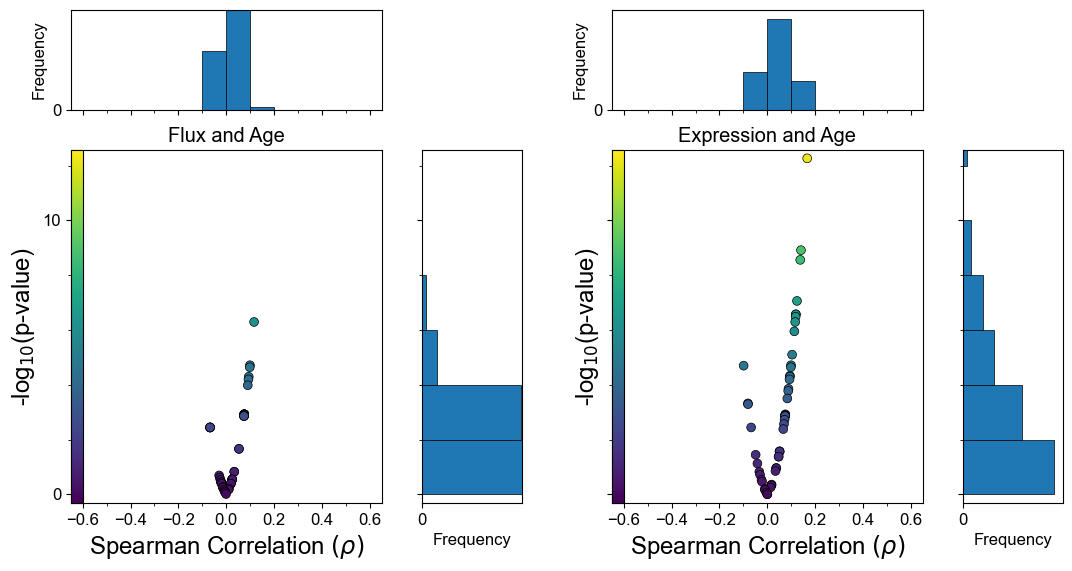

In [29]:
metadata_col = "Age"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)

print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### BMI

Variables                                                   Flux and BMI  \
Spearman correlation                                                 rho   
reaction genes                                                             
DPGM     BPGM;PGAM1                                            -0.149284   
INSt     SLC29A1                                               -0.131398   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...    -0.109966   
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...    -0.109575   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...    -0.107629   
ADNt     SLC29A1                                               -0.105910   
HEX1     HK1;HK3                                               -0.103233   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                   -0.103233   
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                               -0.100853   
ADA      ADA                                                   -0.100853   

Variables  

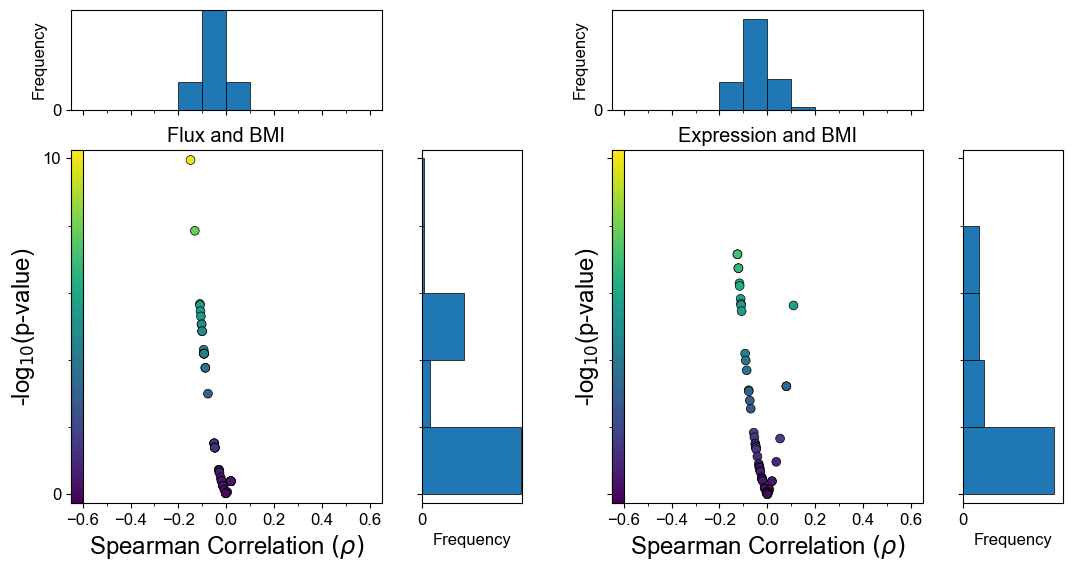

In [30]:
metadata_col = "BMI"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Weight

Variables                                          Flux and Weight  \
Spearman correlation                                           rho   
reaction genes                                                       
HEX1     HK1;HK3                                         -0.188762   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4             -0.188762   
DPGM     BPGM;PGAM1                                      -0.168575   
PYK      PKLR;PKM                                        -0.167292   
ENO      ENO1;ENO2;ENO3                                  -0.167292   
CAATPS1  ATP2B1;ATP2B4                                   -0.167292   
PGK      PGK1;PGK2                                       -0.167292   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3       -0.167292   
DPGase   BPGM                                            -0.167292   
PGM      BPGM;PGAM1                                      -0.167292   

Variables                                                         
Spearman correlation  

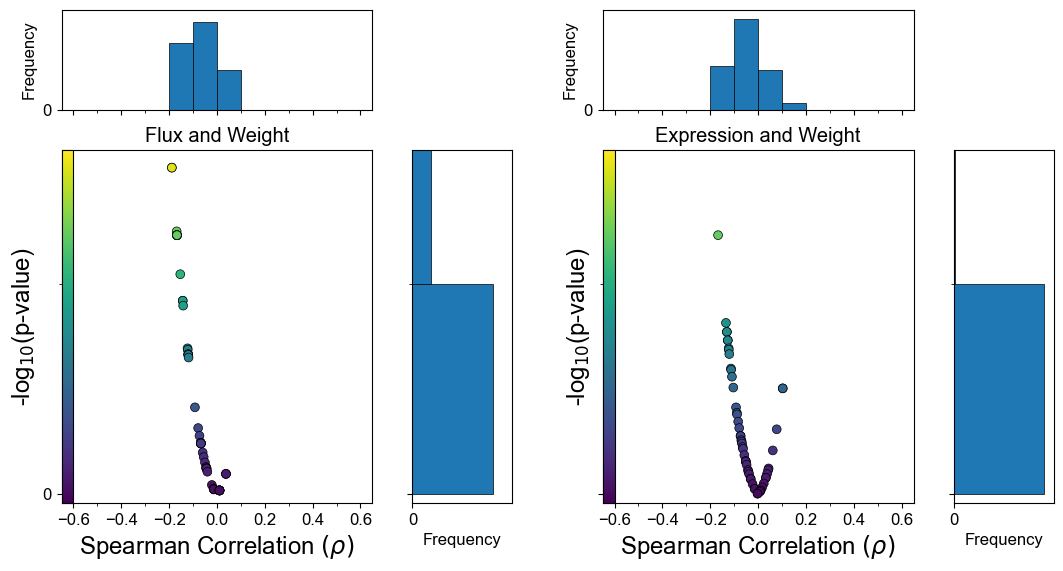

In [31]:
metadata_col = "Weight"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=30,
    ytick_minor=10,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Height

Variables                                          Flux and Height  \
Spearman correlation                                           rho   
reaction genes                                                       
HEX1     HK1;HK3                                         -0.218829   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4             -0.218829   
PYK      PKLR;PKM                                        -0.186956   
ENO      ENO1;ENO2;ENO3                                  -0.186956   
CAATPS1  ATP2B1;ATP2B4                                   -0.186956   
PGK      PGK1;PGK2                                       -0.186956   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3       -0.186956   
DPGase   BPGM                                            -0.186956   
PGM      BPGM;PGAM1                                      -0.186956   
RPI      RPIA                                            -0.167162   

Variables                                                         
Spearman correlation  

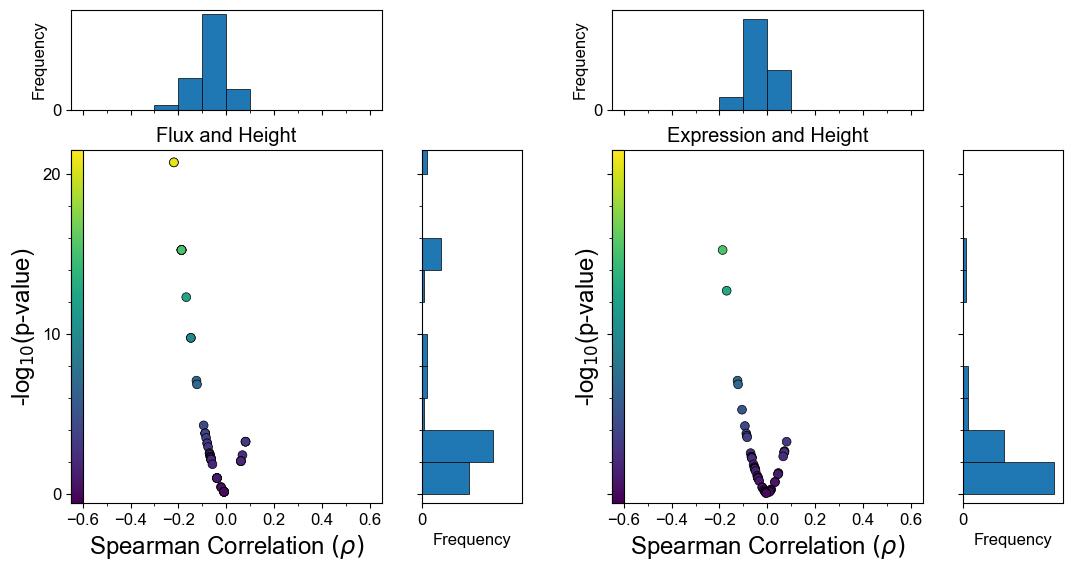

In [32]:
metadata_col = "Height"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.volume

Variables                                                   Flux and Hemolysis.volume  \
Spearman correlation                                                              rho   
reaction genes                                                                          
G6PDH2   G6PD                                                                0.064607   
PGL      PGLS                                                                0.064607   
GTHP     GPX1;GPX4                                                           0.064607   
GTHOy    GSR                                                                 0.064607   
GND      PGD                                                                 0.064607   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...                  0.061449   
PFK      PFKL;PFKM;PFKP                                                     -0.060299   
TPI      TPI1                                                               -0.060299   
FBA      ALDOA;ALDOB;

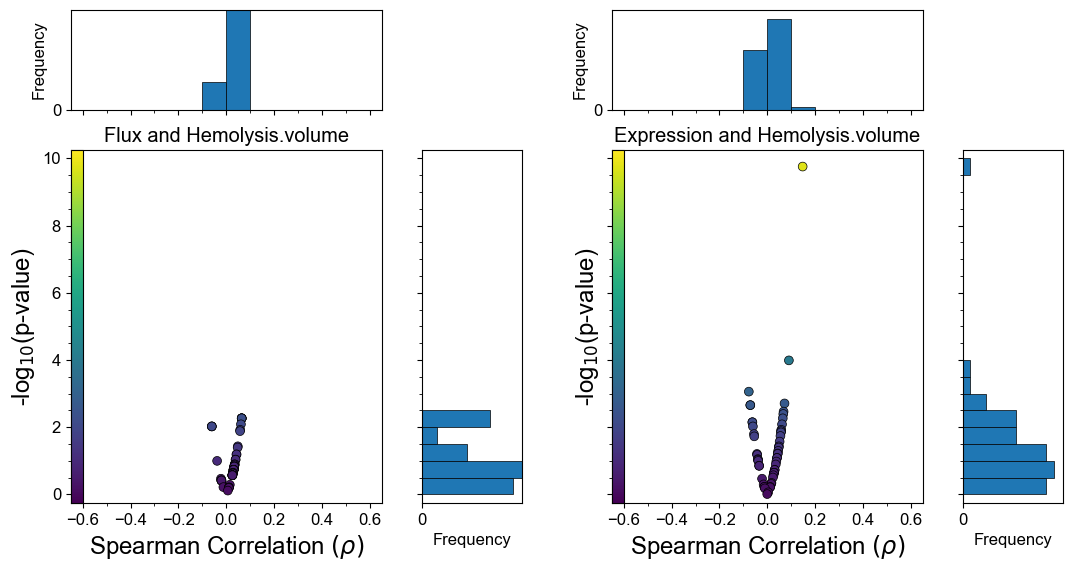

In [33]:
metadata_col = "Hemolysis.volume"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.hct

Variables                                                   Flux and Hemolysis.hct  \
Spearman correlation                                                           rho   
reaction genes                                                                       
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...               0.494007   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...               0.493494   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...               0.491708   
DPGM     BPGM;PGAM1                                                       0.294436   
INSt     SLC29A1                                                          0.266406   
GAPD     GAPDH;GAPDHS                                                     0.260343   
LDH_L    LDHA;LDHB                                                        0.232750   
L_LACt2  BSG;EMB;SLC16A1;SLC16A7                                          0.232750   
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                      

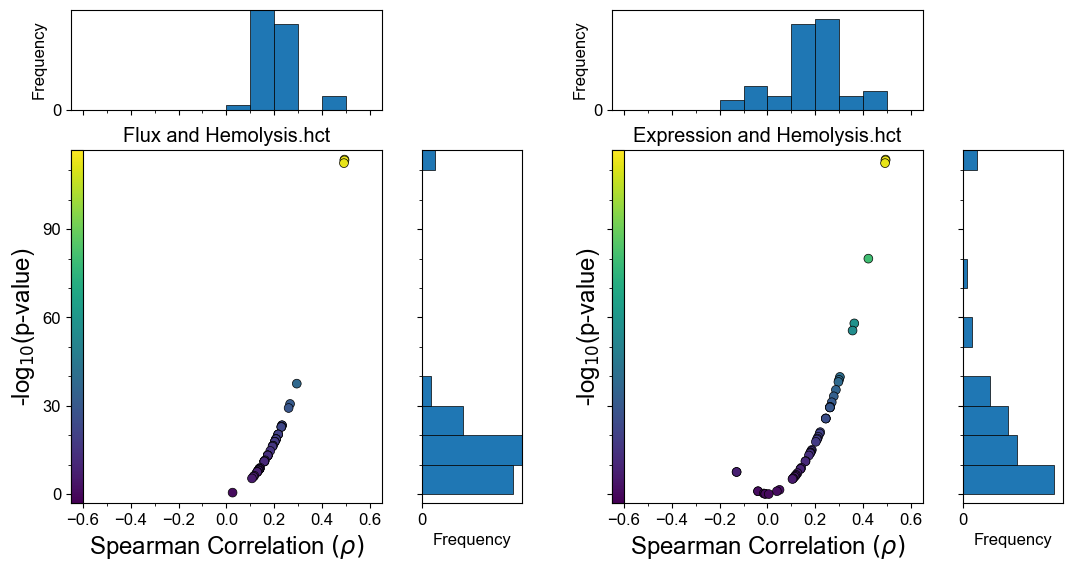

In [34]:
metadata_col = "Hemolysis.hct"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=30,
    ytick_minor=10,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)

axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.storage_total_hb

Variables                                                   Flux and Hemolysis.storage_total_hb  \
Spearman correlation                                                                        rho   
reaction genes                                                                                    
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...                            0.368954   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...                            0.365623   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...                            0.363898   
PFK      PFKL;PFKM;PFKP                                                                0.285615   
TPI      TPI1                                                                          0.285615   
FBA      ALDOA;ALDOB;ALDOC                                                             0.285615   
GAPD     GAPDH;GAPDHS                                                                  0.234666   
DPGM     B

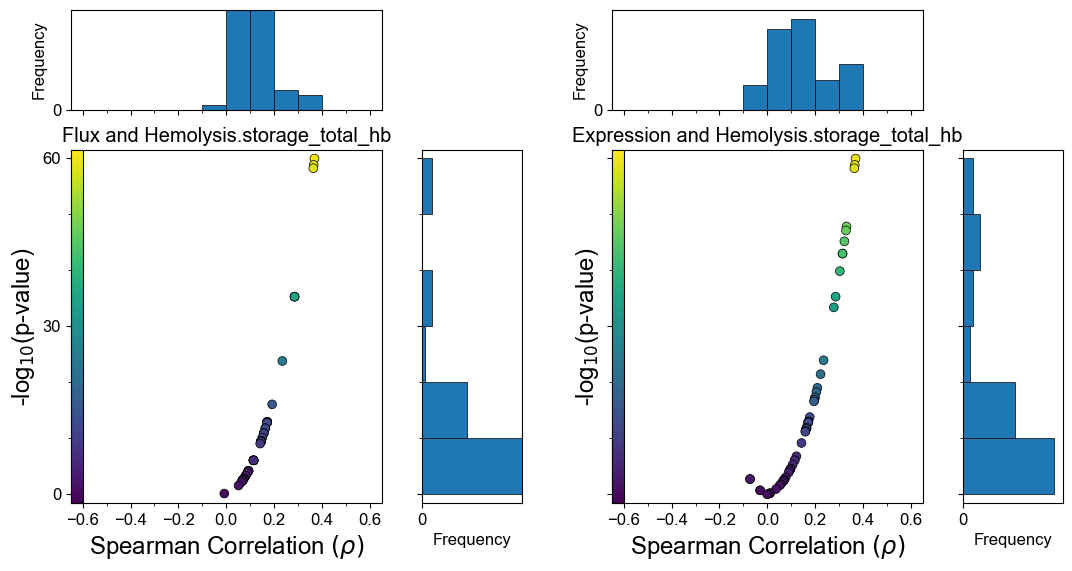

In [35]:
metadata_col = "Hemolysis.storage_total_hb"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=30,
    ytick_minor=10,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.storage_pct_hemol

Variables                                    Flux and Hemolysis.storage_pct_hemol  \
Spearman correlation                                                          rho   
reaction genes                                                                      
INSt     SLC29A1                                                        -0.161986   
DPGM     BPGM;PGAM1                                                     -0.154775   
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                                        -0.148471   
ADA      ADA                                                            -0.148471   
ADNt     SLC29A1                                                        -0.145622   
HEX1     HK1;HK3                                                        -0.141145   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                            -0.141145   
RPI      RPIA                                                           -0.136773   
LDH_L    LDHA;LDHB                                               

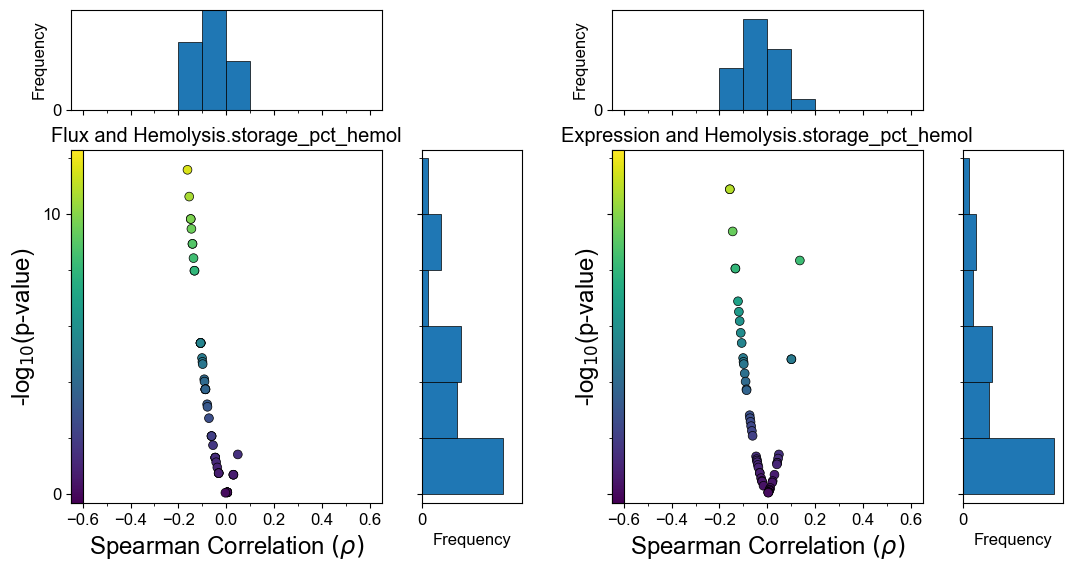

In [36]:
metadata_col = "Hemolysis.storage_pct_hemol"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.pink_total_hb

Variables                                          Flux and Hemolysis.pink_total_hb  \
Spearman correlation                                                            rho   
reaction genes                                                                        
PYK      PKLR;PKM                                                         -0.135743   
ENO      ENO1;ENO2;ENO3                                                   -0.135743   
CAATPS1  ATP2B1;ATP2B4                                                    -0.135743   
PGK      PGK1;PGK2                                                        -0.135743   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3                        -0.135743   
DPGase   BPGM                                                             -0.135743   
PGM      BPGM;PGAM1                                                       -0.135743   
HEX1     HK1;HK3                                                          -0.122018   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A

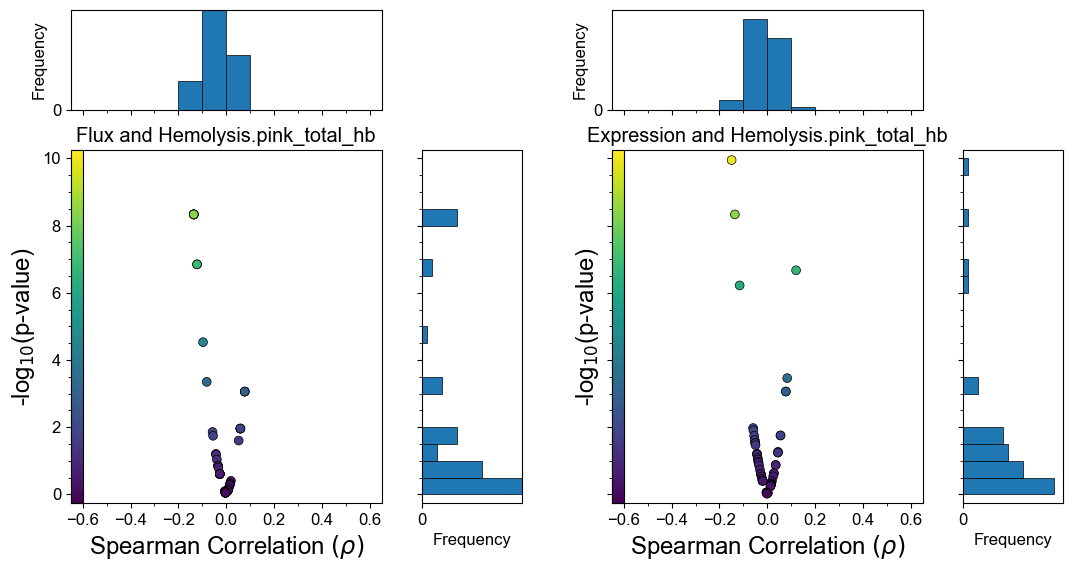

In [37]:
metadata_col = "Hemolysis.pink_total_hb"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.pink_pct_hemol

Variables                                    Flux and Hemolysis.pink_pct_hemol  \
Spearman correlation                                                       rho   
reaction genes                                                                   
RPI      RPIA                                                        -0.177885   
HEX1     HK1;HK3                                                     -0.173007   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                         -0.173007   
PFK      PFKL;PFKM;PFKP                                               0.157122   
TPI      TPI1                                                         0.157122   
FBA      ALDOA;ALDOB;ALDOC                                            0.157122   
H2Ot     AQP1;AQP3                                                   -0.132095   
O2t      AQP1                                                        -0.131029   
PYK      PKLR;PKM                                                    -0.124339   
ENO      ENO1;EN

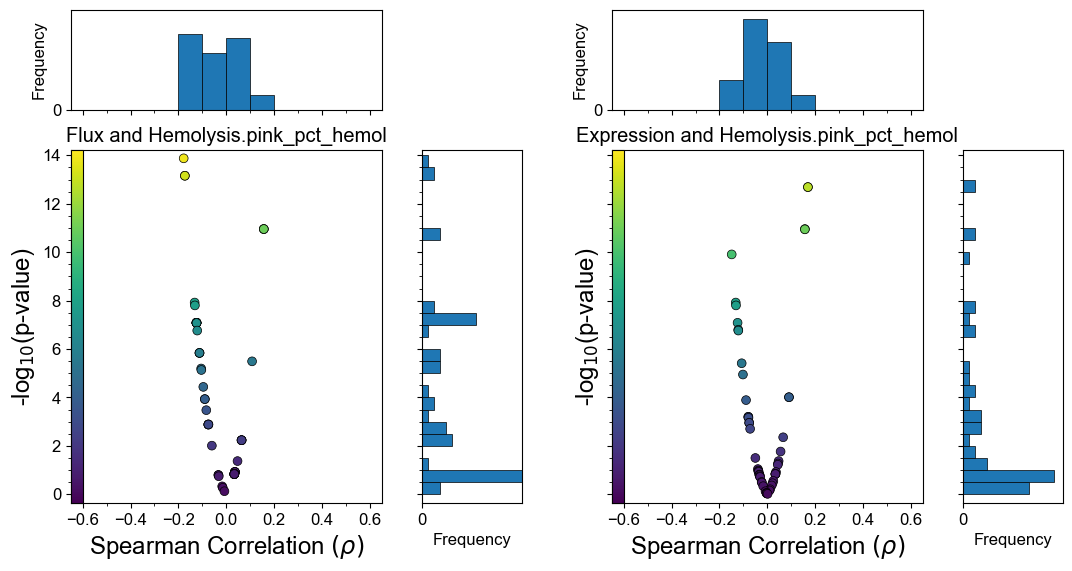

In [38]:
metadata_col = "Hemolysis.pink_pct_hemol"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Recall.Transfer.Storage.Hemolysis

Variables                                          Flux and Recall.Transfer.Storage.Hemolysis  \
Spearman correlation                                                                      rho   
reaction genes                                                                                  
HEX1     HK1;HK3                                                                    -0.142137   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                                        -0.142137   
PYK      PKLR;PKM                                                                   -0.134929   
ENO      ENO1;ENO2;ENO3                                                             -0.134929   
CAATPS1  ATP2B1;ATP2B4                                                              -0.134929   
PGK      PGK1;PGK2                                                                  -0.134929   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3                                  -0.134929   
DPGase   BPGM                 

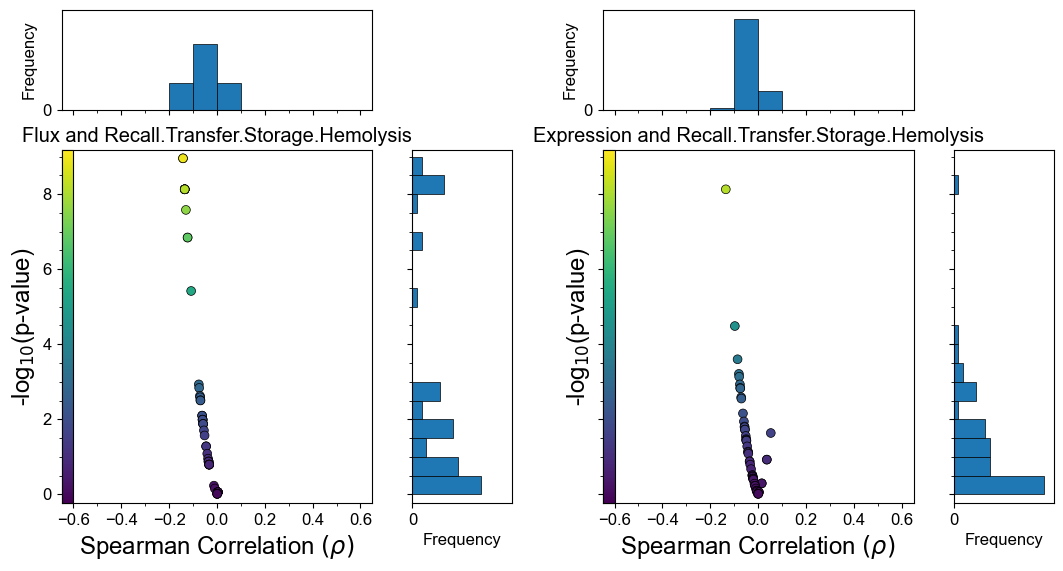

In [39]:
metadata_col = "Recall.Transfer.Storage.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Recall.Transfer.Osmotic.Hemolysis

Variables                                    Flux and Recall.Transfer.Osmotic.Hemolysis  \
Spearman correlation                                                                rho   
reaction genes                                                                            
HEX1     HK1;HK3                                                              -0.183870   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                                  -0.183870   
PFK      PFKL;PFKM;PFKP                                                        0.181071   
TPI      TPI1                                                                  0.181071   
FBA      ALDOA;ALDOB;ALDOC                                                     0.181071   
RPI      RPIA                                                                 -0.169167   
PYK      PKLR;PKM                                                             -0.150569   
ENO      ENO1;ENO2;ENO3                                                       -0.150569   

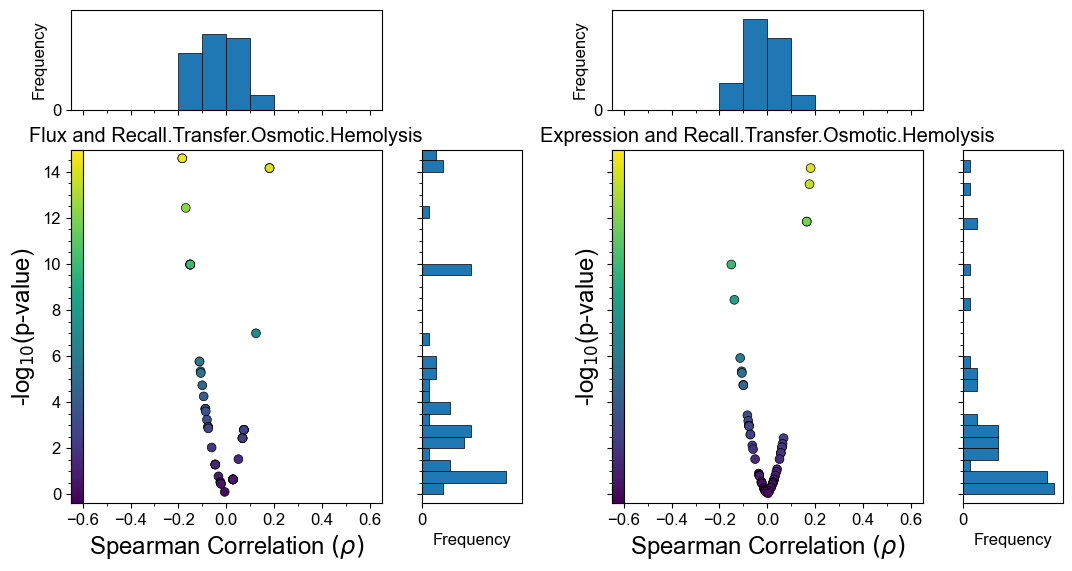

In [40]:
metadata_col = "Recall.Transfer.Osmotic.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Recall.Transfer.Oxidative.Hemolysis

Variables                                                   Flux and Recall.Transfer.Oxidative.Hemolysis  \
Spearman correlation                                                                                 rho   
reaction genes                                                                                             
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...                                    -0.198160   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...                                    -0.197166   
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...                                    -0.195866   
INSt     SLC29A1                                                                               -0.193538   
ADNt     SLC29A1                                                                               -0.184893   
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                                                               -0.174958   
ADA      ADA                

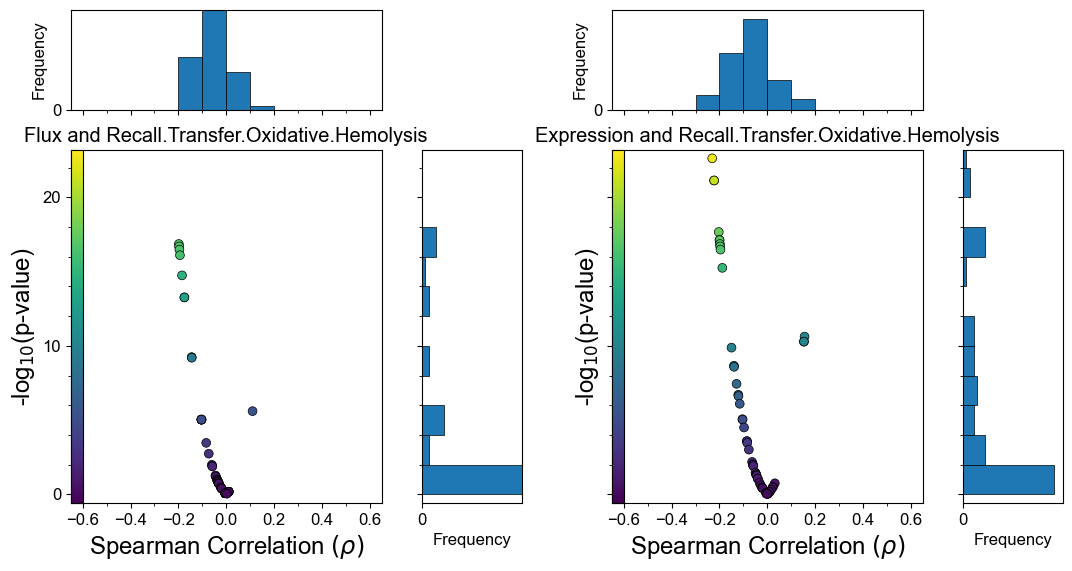

In [41]:
metadata_col = "Recall.Transfer.Oxidative.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Adjusted.Storage.Hemolysis

Variables                                    Flux and Adjusted.Storage.Hemolysis  \
Spearman correlation                                                         rho   
reaction genes                                                                     
INSt     SLC29A1                                                       -0.158011   
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                                       -0.142037   
ADA      ADA                                                           -0.142037   
ADNt     SLC29A1                                                       -0.141035   
DPGM     BPGM;PGAM1                                                    -0.139777   
HEX1     HK1;HK3                                                       -0.135759   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                           -0.135759   
RPI      RPIA                                                          -0.128760   
LDH_L    LDHA;LDHB                                                     -0.11

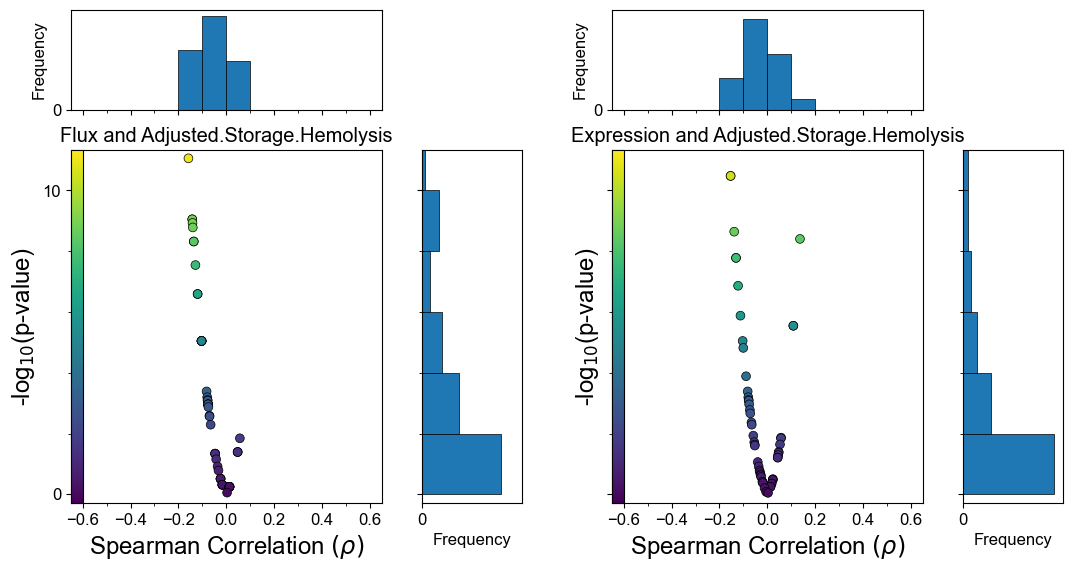

In [42]:
metadata_col = "Adjusted.Storage.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Adjusted.Osmotic.Hemolysis

Variables                                    Flux and Adjusted.Osmotic.Hemolysis  \
Spearman correlation                                                         rho   
reaction genes                                                                     
PFK      PFKL;PFKM;PFKP                                                 0.208491   
TPI      TPI1                                                           0.208491   
FBA      ALDOA;ALDOB;ALDOC                                              0.208491   
GAPD     GAPDH;GAPDHS                                                   0.156983   
RPI      RPIA                                                          -0.129913   
HEX1     HK1;HK3                                                       -0.120880   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                           -0.120880   
O2t      AQP1                                                          -0.105418   
H2Ot     AQP1;AQP3                                                     -0.10

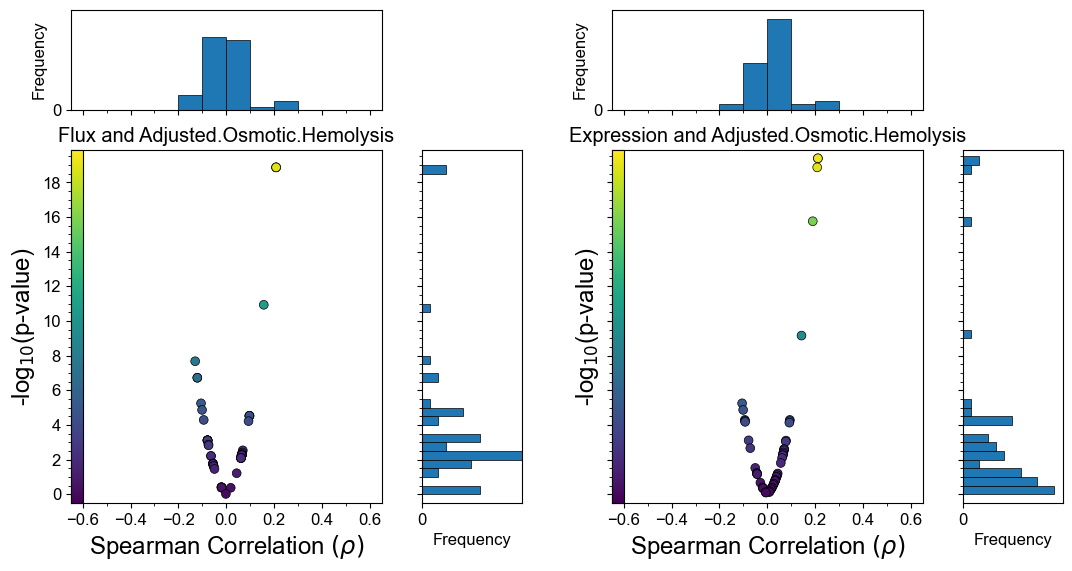

In [43]:
metadata_col = "Adjusted.Osmotic.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Adjusted.Oxidative.Hemolysis

Variables                                                   Flux and Adjusted.Oxidative.Hemolysis  \
Spearman correlation                                                                          rho   
reaction genes                                                                                      
PYRt2    BSG;EMB;SLC16A1;SLC16A7                                                        -0.075945   
PGI      GPI                                                                            -0.068261   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...                             -0.061137   
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...                             -0.061014   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...                             -0.059600   
PYK      PKLR;PKM                                                                       -0.055843   
ENO      ENO1;ENO2;ENO3                                                                 -0.

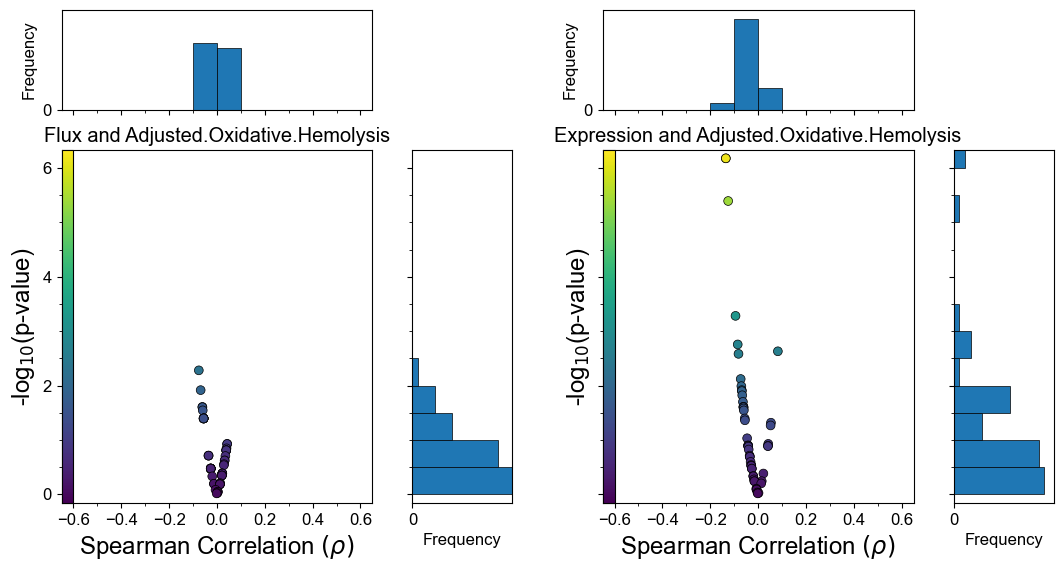

In [44]:
metadata_col = "Adjusted.Oxidative.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.WBC

Variables                      Flux and CBC.WBC          
Spearman correlation                        rho    pvalue
reaction genes                                           
PGI      GPI                           0.078046  0.000884
NTDAMP   NT5C2                         0.076548  0.001110
NTDIMP   NT5C2                         0.076548  0.001110
ADNK1    ADK                           0.076548  0.001110
HXPRT    HPRT1                         0.076548  0.001110
PPA      LHPP;PPA1;PPA2;PRUNE1         0.076548  0.001110
PRPPS    PRPS1;PRPS1L1;PRPS2           0.076548  0.001110
ADK1     AK1                           0.076548  0.001110
ADPT     APRT                          0.076548  0.001110
ADEt     SLC29A1;SLC43A3               0.076548  0.001110

Variables                                          Expression and CBC.WBC  \
Spearman correlation                                                  rho   
reaction genes                                                              
PGI      GPI  

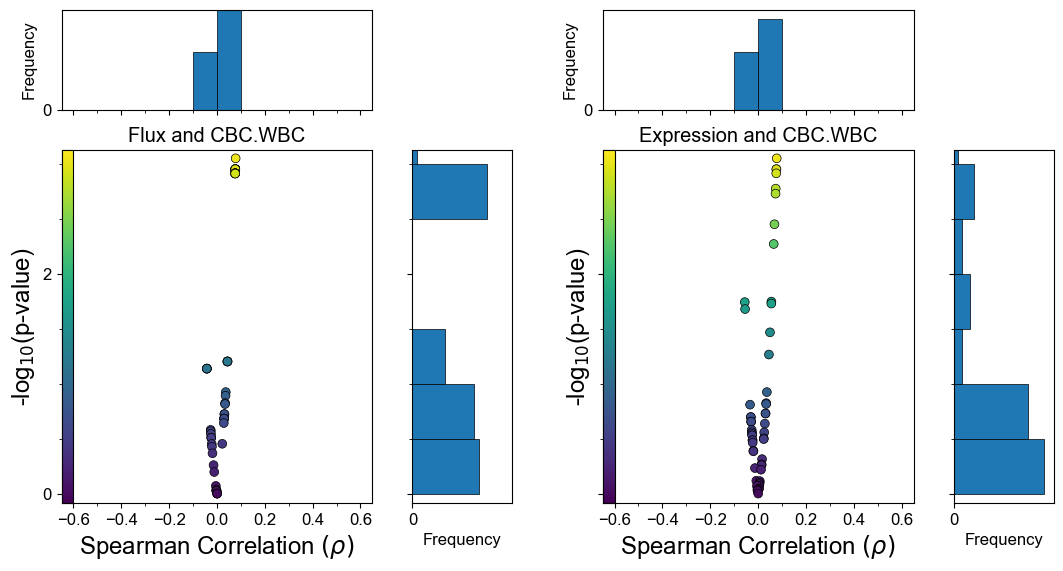

In [45]:
metadata_col = "CBC.WBC"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.RBC

Variables                                    Flux and CBC.RBC              
Spearman correlation                                      rho        pvalue
reaction genes                                                             
INSt     SLC29A1                                    -0.181740  6.395542e-15
ADNt     SLC29A1                                    -0.161117  5.246636e-12
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                    -0.155679  2.683578e-11
ADA      ADA                                        -0.155679  2.683578e-11
HEX1     HK1;HK3                                    -0.147911  2.504951e-10
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4        -0.147911  2.504951e-10
RPI      RPIA                                       -0.138632  3.108009e-09
H2Ot     AQP1;AQP3                                  -0.123777  1.252944e-07
O2t      AQP1                                       -0.122712  1.607906e-07
LDH_L    LDHA;LDHB                                  -0.104760  7.872628e-06

Variables  

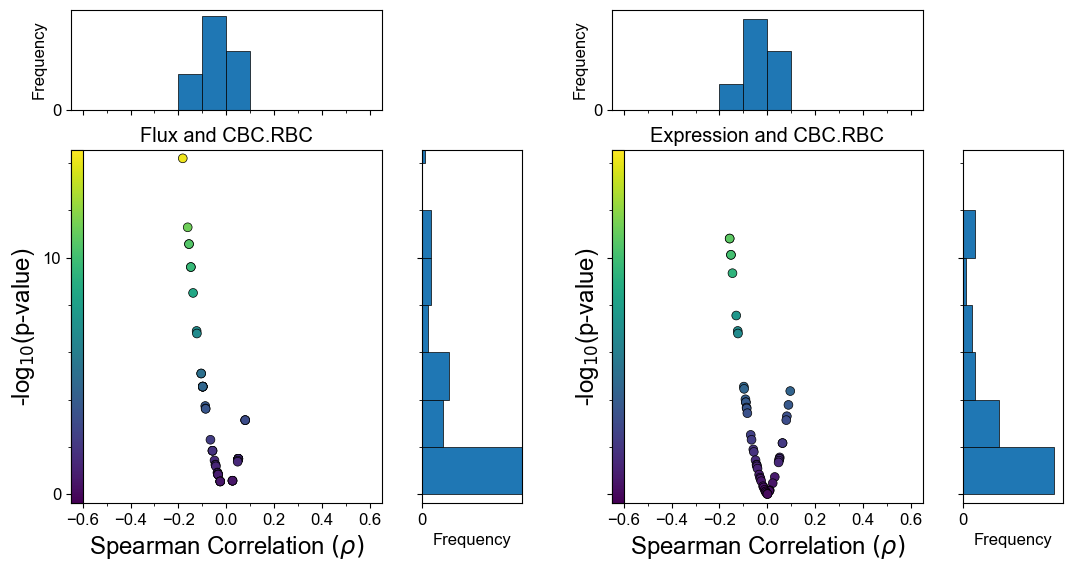

In [46]:
metadata_col = "CBC.RBC"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.HGB

Variables                                          Flux and CBC.HGB  \
Spearman correlation                                            rho   
reaction genes                                                        
HEX1     HK1;HK3                                          -0.239110   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4              -0.239110   
PYK      PKLR;PKM                                         -0.203131   
ENO      ENO1;ENO2;ENO3                                   -0.203131   
CAATPS1  ATP2B1;ATP2B4                                    -0.203131   
PGK      PGK1;PGK2                                        -0.203131   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3        -0.203131   
DPGase   BPGM                                             -0.203131   
PGM      BPGM;PGAM1                                       -0.203131   
RPI      RPIA                                             -0.182198   

Variables                                                         
Spearman 

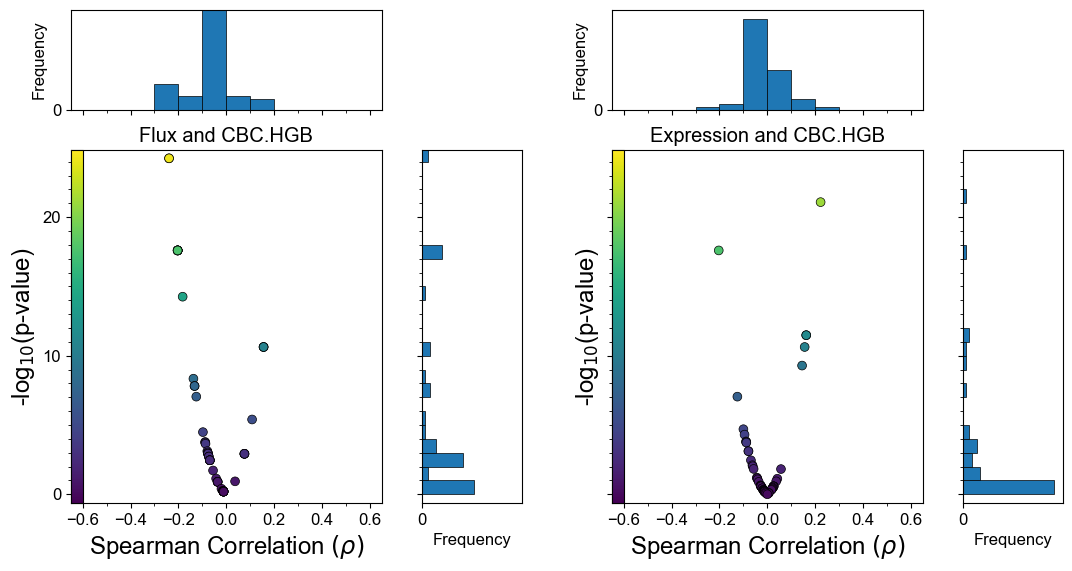

In [47]:
metadata_col = "CBC.HGB"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=800,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=1,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=800,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.HCT

Variables                                    Flux and CBC.HCT              
Spearman correlation                                      rho        pvalue
reaction genes                                                             
HEX1     HK1;HK3                                    -0.187164  9.534334e-16
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4        -0.187164  9.534334e-16
RPI      RPIA                                       -0.156031  2.418250e-11
PFK      PFKL;PFKM;PFKP                              0.150023  1.380144e-10
TPI      TPI1                                        0.150023  1.380144e-10
FBA      ALDOA;ALDOB;ALDOC                           0.150023  1.380144e-10
PYK      PKLR;PKM                                   -0.140131  2.091760e-09
ENO      ENO1;ENO2;ENO3                             -0.140131  2.091760e-09
CAATPS1  ATP2B1;ATP2B4                              -0.140131  2.091760e-09
PGK      PGK1;PGK2                                  -0.140131  2.091760e-09

Variables  

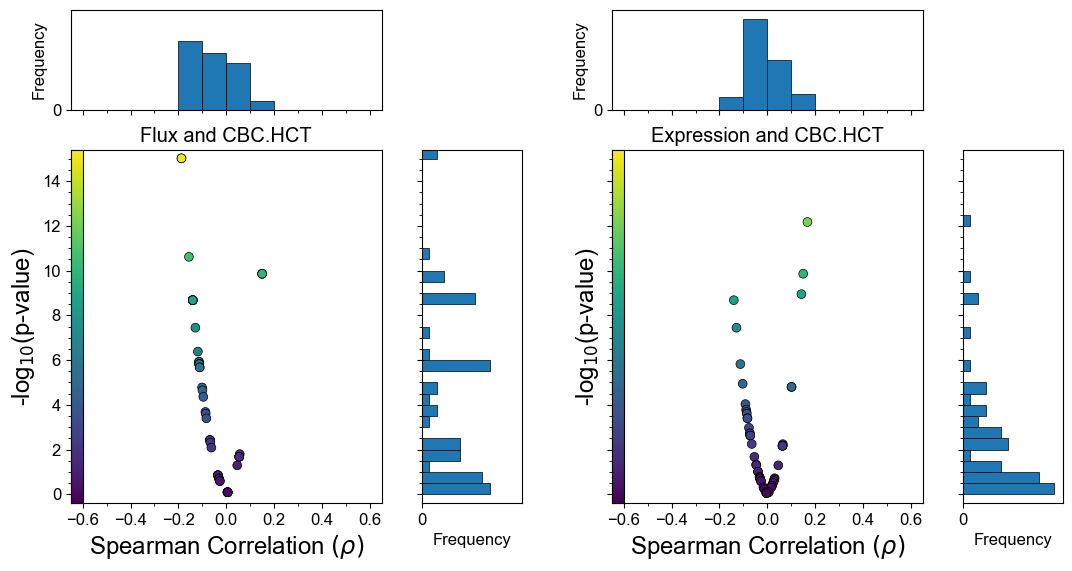

In [48]:
metadata_col = "CBC.HCT"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)

if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.MCV

Variables                        Flux and CBC.MCV              
Spearman correlation                          rho        pvalue
reaction genes                                                 
INSt     SLC29A1                         0.136897  4.888590e-09
ADNt     SLC29A1                         0.121952  1.918431e-07
NH4t     AQP1;AQP3;RHAG;RHCE;RHD         0.095706  4.493602e-05
ADA      ADA                             0.095706  4.493602e-05
H2Ot     AQP1;AQP3                       0.093733  6.441599e-05
O2t      AQP1                            0.092789  7.633758e-05
G6PDH2   G6PD                           -0.075145  1.369173e-03
PGL      PGLS                           -0.075145  1.369173e-03
GTHP     GPX1;GPX4                      -0.075145  1.369173e-03
GTHOy    GSR                            -0.075145  1.369173e-03

Variables                    Expression and CBC.MCV              
Spearman correlation                            rho        pvalue
reaction genes                     

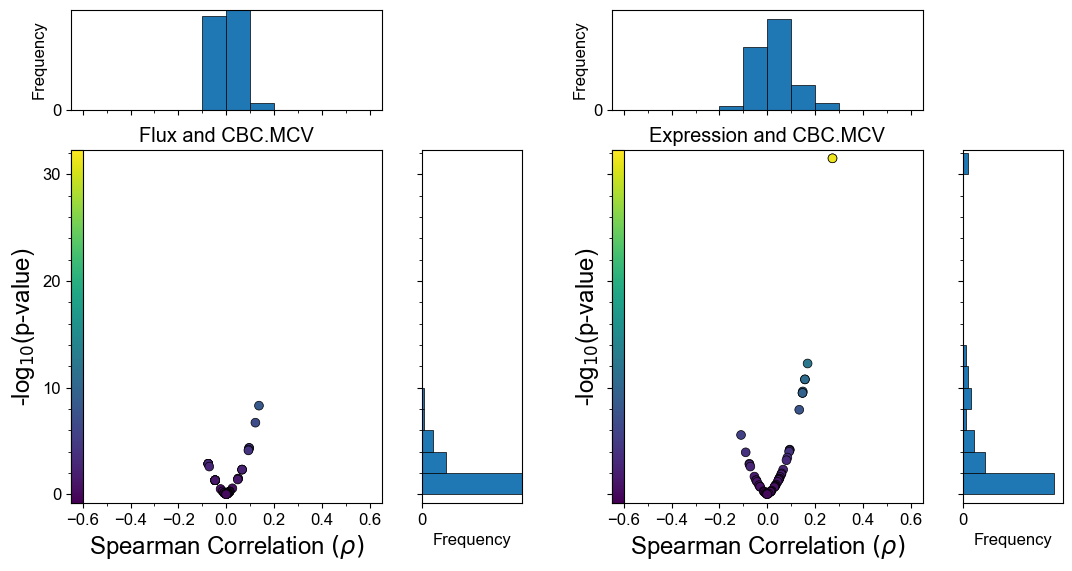

In [49]:
metadata_col = "CBC.MCV"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.RDW

Variables                                                     Flux and CBC.RDW  \
Spearman correlation                                                       rho   
reaction   genes                                                                 
PFK        PFKL;PFKM;PFKP                                            -0.122421   
TPI        TPI1                                                      -0.122421   
FBA        ALDOA;ALDOB;ALDOC                                         -0.122421   
GAPD       GAPDH;GAPDHS                                              -0.113774   
SPODM      SOD1                                                      -0.112096   
FCYTOB5OXR CYB5A;CYB5B;CYB5R3                                        -0.112096   
METHBCYTBR CYB5A;CYB5B;HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1...        -0.112096   
OXYHBAOX   HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ                   -0.112096   
HB23DPGB   HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ                   -0.088262   
PYRt2      BSG;E

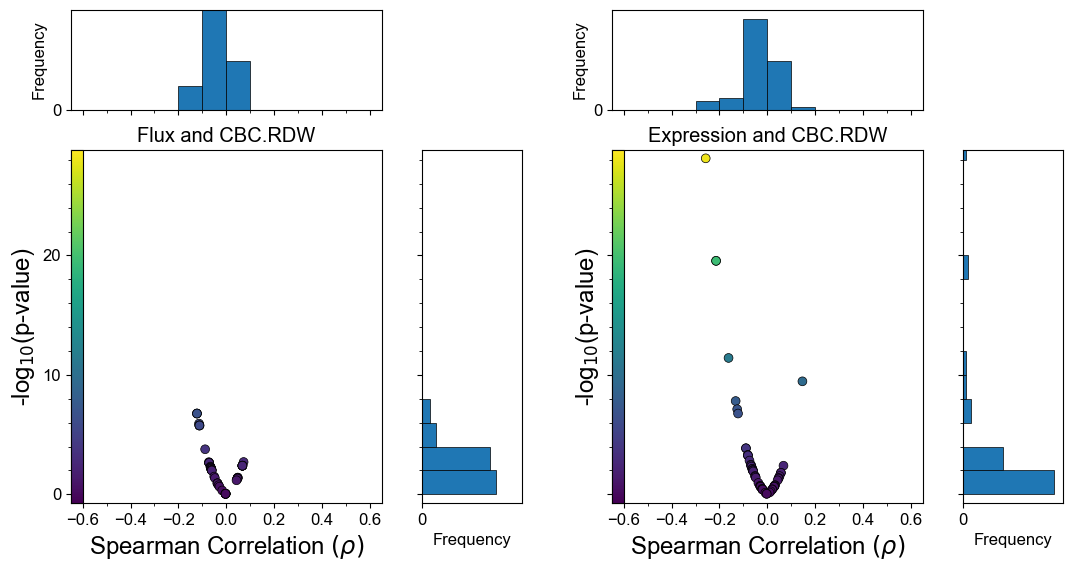

In [50]:
metadata_col = "CBC.RDW"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.PLT

Variables                                          Flux and CBC.PLT  \
Spearman correlation                                            rho   
reaction genes                                                        
HEX1     HK1;HK3                                           0.185669   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4               0.185669   
PYK      PKLR;PKM                                          0.159985   
ENO      ENO1;ENO2;ENO3                                    0.159985   
CAATPS1  ATP2B1;ATP2B4                                     0.159985   
PGK      PGK1;PGK2                                         0.159985   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3         0.159985   
DPGase   BPGM                                              0.159985   
PGM      BPGM;PGAM1                                        0.159985   
LDH_L    LDHA;LDHB                                         0.146332   

Variables                                                         
Spearman 

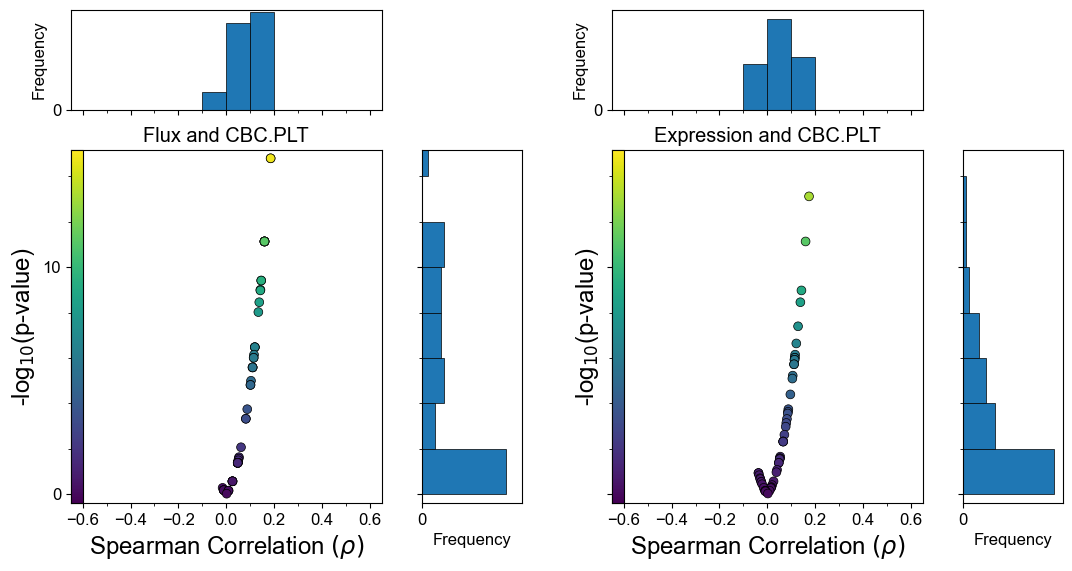

In [51]:
metadata_col = "CBC.PLT"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Ferritin

Variables                                          Flux and Ferritin  \
Spearman correlation                                             rho   
reaction genes                                                         
PYK      PKLR;PKM                                          -0.187435   
ENO      ENO1;ENO2;ENO3                                    -0.187435   
CAATPS1  ATP2B1;ATP2B4                                     -0.187435   
PGK      PGK1;PGK2                                         -0.187435   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3         -0.187435   
DPGase   BPGM                                              -0.187435   
PGM      BPGM;PGAM1                                        -0.187435   
HEX1     HK1;HK3                                           -0.179772   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4               -0.179772   
PYRt2    BSG;EMB;SLC16A1;SLC16A7                           -0.158347   

Variables                                                      

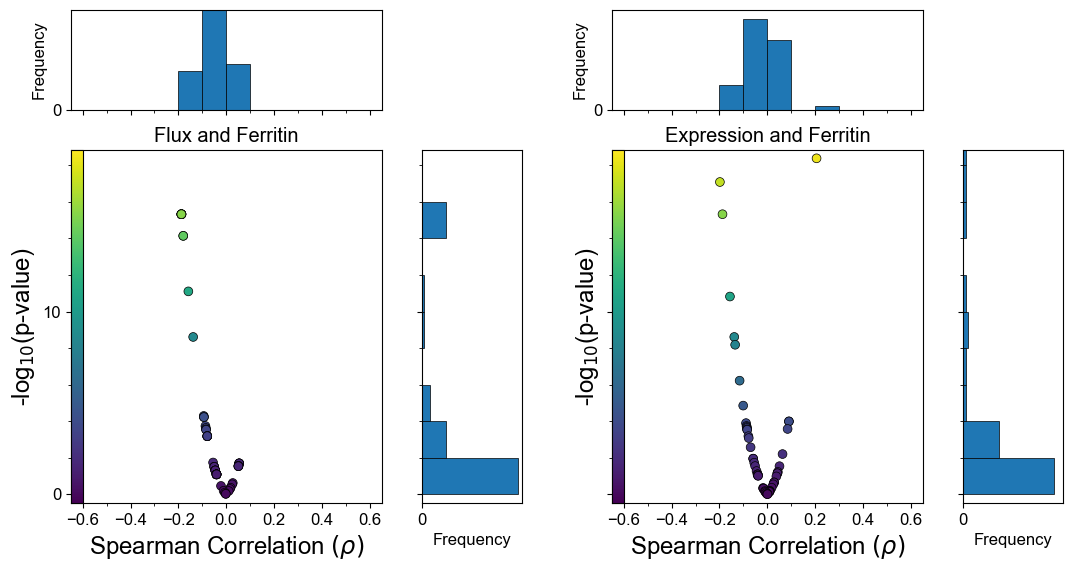

In [52]:
metadata_col = "Ferritin"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;